# ABU 量化系统  简介（版本 0.1）

* #### __author__ = 'BBFamily'
* ####  __email__ = 'bbfamily@126.com'

## 第七部分 解决方案A

## ‘非均衡胜负收益’带来的必然’非均衡胜负比例‘，目标由’因子‘的能力解决一部分，’模式识别‘提升关键的一部分

## 使用黄金分割因子作为交易因子，黄金分割因子具体查看BuyGoldenFactor
_____

In [1]:
import ZEnv
import ZLog
import ZCommonUtil
%matplotlib inline

In [2]:
import WinLossAlloc

为黄金分割因子寻找最优止盈止损方案:
    
        回弹策略具体查看：
                WinLossAlloc.init_golden_w_full 
                WinLossAlloc.golden_map_wl_grid

因子在两条382之间设置买入触发一定条件买入，需找支持阻力策略

**理解更多因子策略，请查看BuyGoldenFactor**
       
         
         使用各个阻力支撑回弹策略，建立层级止盈止损策略
         暂定0.42为胜率阀值目标
         
         
         收益取消计算了交易成本

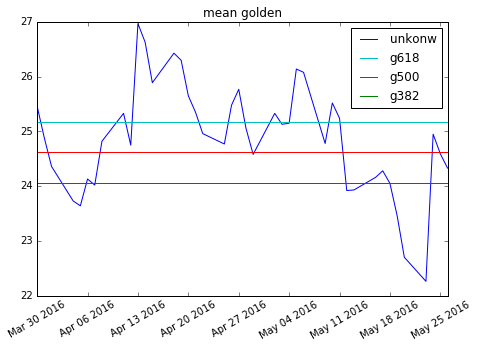

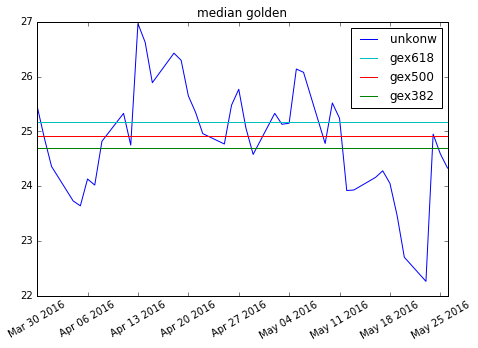

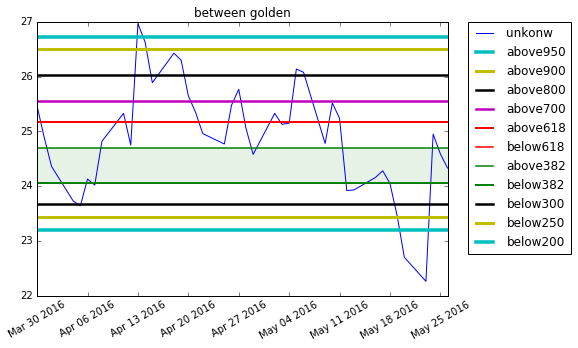

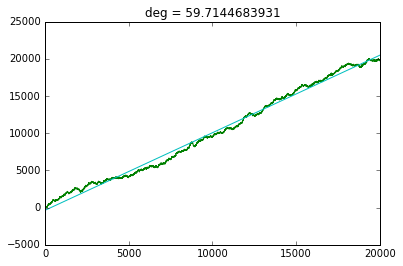

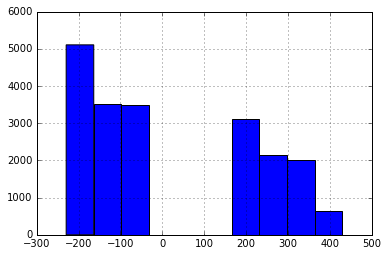

In [6]:
WinLossAlloc.show_golden_process(0.42)

**使用蒙特卡洛方法分析最优**

1. 输赢比例
2. 输赢资金的比例
3. 最后总收益

从图中很明显受益的关键是输赢资金的比例，所以思路最优输赢资金的比例

* n_jobs=-1 使用并行加速
* 所有函数名称带nb的使用numba做编译加速处理，但效果一般，且使用numba会有一些限制条件

In [27]:
filter(lambda func: func.startswith('show_golden'), dir(WinLossAlloc)) 

['show_golden_mc_nb_process',
 'show_golden_mc_nb_product_process',
 'show_golden_mc_process',
 'show_golden_mc_product_process',
 'show_golden_nb_process',
 'show_golden_process',
 'show_golden_sco_process']

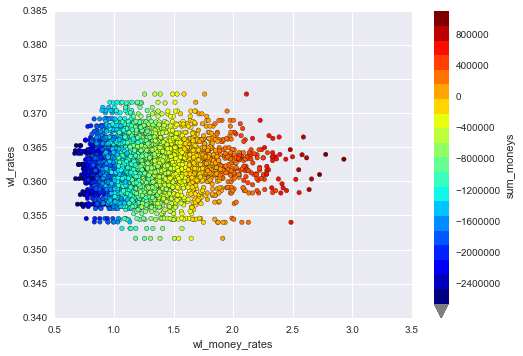

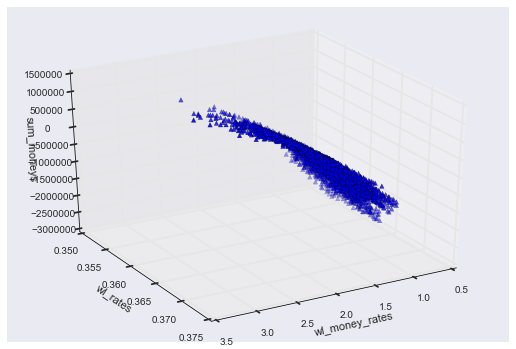

CPU times: user 23.2 s, sys: 2.12 s, total: 25.3 s
Wall time: 12min 56s


,wl_money_rates,wl_rates,sum_moneys,keys
0,0.891952,0.3635,-1.63938e+06,"[0.0, 0.05457142857142857, 0.1637142857142857,..."
1,1.01011,0.356,-1.52894e+06,"[0.05457142857142857, 0.10914285714285714, 0.1..."
2,1.20383,0.3625,-967466,"[0.05457142857142857, 0.10914285714285714, 0.2..."
3,2.01064,0.36465,269489,"[0.1637142857142857, 0.27285714285714285, 0.32..."
4,1.76798,0.36095,-3839.36,"[0.05457142857142857, 0.1637142857142857, 0.27..."
5,1.0985,0.3655,-1.22862e+06,"[0.0, 0.05457142857142857, 0.1637142857142857,..."
6,0.778013,0.3588,-2.10669e+06,"[0.0, 0.05457142857142857, 0.10914285714285714..."
7,0.798216,0.3644,-2.20691e+06,"[0.0, 0.05457142857142857, 0.10914285714285714..."
8,0.963606,0.3626,-1.52909e+06,"[0.0, 0.10914285714285714, 0.21828571428571428..."
9,2.41111,0.35965,712279,"[0.05457142857142857, 0.27285714285714285, 0.3..."


In [15]:
# n_jobs=-1 默认启动8个进程
%time wl_pd = WinLossAlloc.show_golden_mc_product_process(0.42, n_jobs=-1)
wl_pd

In [7]:
wl_pd['sum_moneys'].mean(), wl_pd['wl_rates'].mean(), wl_pd['wl_money_rates'].mean()

(-864315.65289616643, 0.3627452551020427, 1.2838664138749722)

In [8]:
import pandas as pd
pd.qcut(wl_pd['wl_money_rates'], 100).value_counts().head()

(2.261, 2.932]    40
(1.501, 1.517]    40
(0.853, 0.869]    40
(0.917, 0.928]    40
(0.966, 0.974]    40
Name: wl_money_rates, dtype: int64

In [47]:
pd.qcut(wl_pd['sum_moneys'], 10).value_counts()

(-36719.399, 1076124.618]        392
(-303973.474, -36719.399]        392
(-513004.66, -303973.474]        392
(-693225.429, -513004.66]        392
(-863807.44, -693225.429]        392
(-1030196.964, -863807.44]       392
(-1203445.107, -1030196.964]     392
(-1411747.792, -1203445.107]     392
(-1702965.0821, -1411747.792]    392
[-2632151.962, -1702965.0821]    392
Name: sum_moneys, dtype: int64

求解最优方程方法：

            bnds = list((0, 0.382) for _ in range(g_mc_loss_cnt)) + list((0.618, 1) for _ in range(g_mc_win_cnt))
            opts = sco.minimize(min_func_st(how), guess_loss_precent + guess_win_precent, method='SLSQP',
                                bounds=bnds, options={'maxiter': max_iter})
                                
            容易陷入局部最优，且不要太精度

In [18]:
opts, min_func = WinLossAlloc.show_golden_sco_process(0.42, how='sum_money')
ZLog.info(opts)
x_array = sorted(opts['x'])
ZLog.info(x_array)
min_func(x_array)

     fun: 557967.14914287545
     jac: array([  1.74875696e+12,   1.90717944e+12,   6.55477947e+11,
         2.95126970e+12,  -4.26034585e+11,  -1.51503668e+11,
        -3.44412792e+12,   4.65515045e+12,  -2.24861638e+12,
         0.00000000e+00])
 message: 'Inequality constraints incompatible'
    nfev: 11
     nit: 1
    njev: 1
  status: 4
 success: False
       x: array([ 0.382     ,  0.16371429,  0.10914286,  0.27285714,  0.83628571,
        0.618     ,  0.94542857,  1.        ,  0.67257143])
[0.10914285714285714, 0.1637142857142857, 0.27285714285714285, 0.38200000000000001, 0.61799999999999999, 0.6725714285714286, 0.8362857142857143, 0.9454285714285714, 1.0]


array([  1.38912949e+00,   3.60650000e-01,  -5.24764131e+05])

**把所有写入hdf5的数据写入不同的文件，由于一个key层数据写坏了将导致整个HDF5文件不可用，所以分开各个写入**

In [5]:
# fn = './data/cache/wl_pd_abu'
# key = 'wl_pd_abu'
# ZCommonUtil.dump_hdf5(wl_pd, key, fn)

In [6]:
# wl_pd = ZCommonUtil.load_hdf5(fn, key)

**所以从mc 最优结果里筛选, 或者使用全局最优brust求解**
        
        从图分析，限制条件，找到n个解

In [29]:
filter_pd = wl_pd[(wl_pd['wl_money_rates'] > 2.5) & (wl_pd['wl_rates'] > 0.36)]

In [30]:
filter_pd

,wl_money_rates,wl_rates,sum_moneys,keys
18,2.61469,0.36015,830115,"[0.1637142857142857, 0.27285714285714285, 0.32..."
83,2.5322,0.3648,743454,"[0.21828571428571428, 0.27285714285714285, 0.3..."
679,2.51328,0.36545,724073,"[0.21828571428571428, 0.27285714285714285, 0.3..."
825,2.7331,0.3685,1.03704e+06,"[0.1637142857142857, 0.27285714285714285, 0.32..."
1150,2.53341,0.3608,707162,"[0.21828571428571428, 0.27285714285714285, 0.3..."
1470,2.6576,0.37005,905439,"[0.21828571428571428, 0.27285714285714285, 0.3..."
1632,2.6427,0.36295,830895,"[0.21828571428571428, 0.27285714285714285, 0.3..."
2280,2.50464,0.3606,681547,"[0.21828571428571428, 0.27285714285714285, 0.3..."
3288,2.93204,0.36055,1.07612e+06,"[0.21828571428571428, 0.27285714285714285, 0.3..."
3423,2.58512,0.36455,893374,"[0.10914285714285714, 0.27285714285714285, 0.3..."


**可视化人工从这n个里挑选最合适的**

柱状要分布均匀，且达成非均衡
这里选择4号分布，阻力支撑保持非均衡，且200-500全分部，下降均匀

0
[0.1637142857142857, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7271428571428571, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


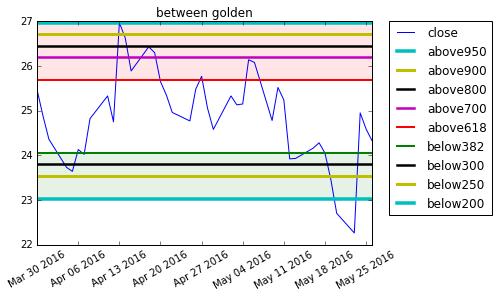

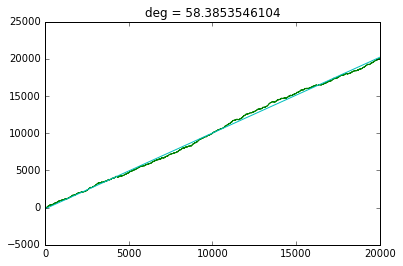

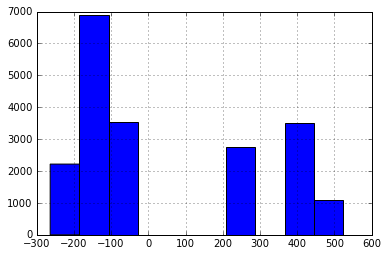

1
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7271428571428571, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 1.0]


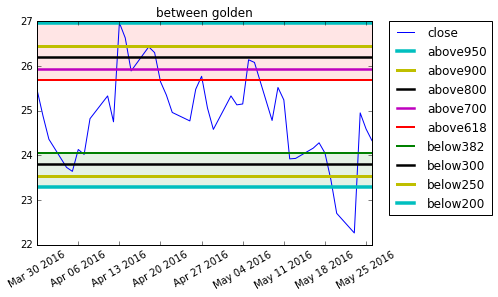

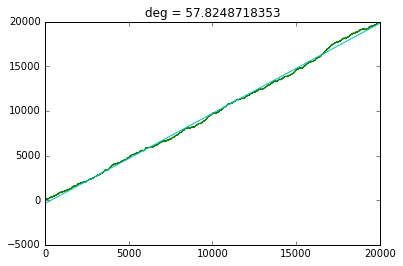

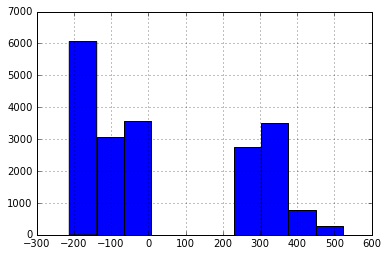

2
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.618, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


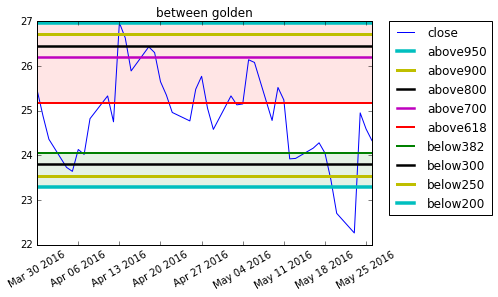

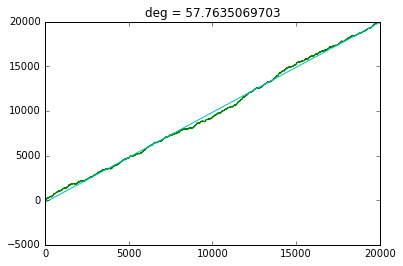

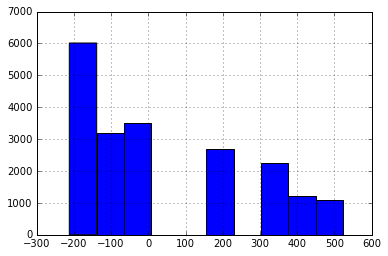

3
[0.1637142857142857, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


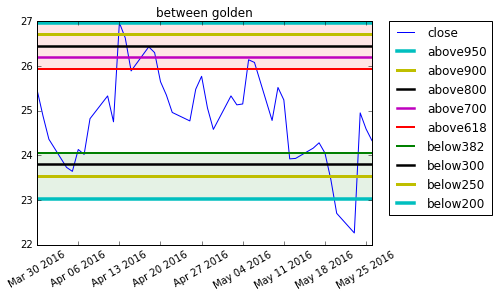

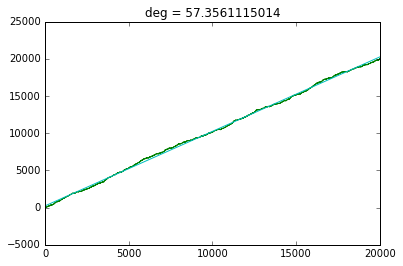

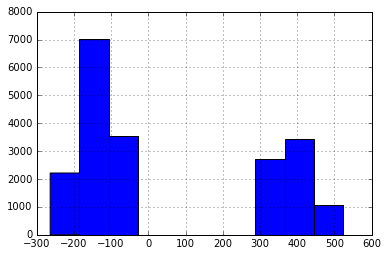

4
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7271428571428571, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714]


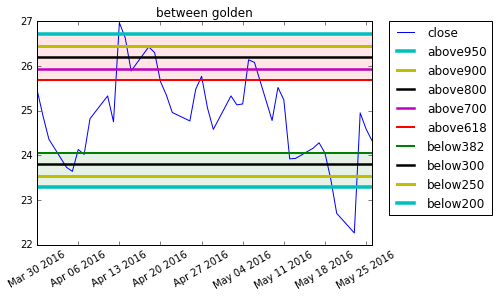

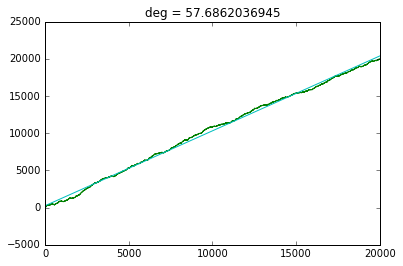

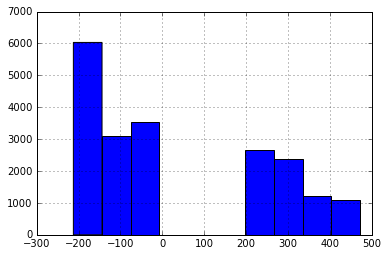

5
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7271428571428571, 0.7817142857142857, 0.8908571428571428, 0.9454285714285714, 1.0]


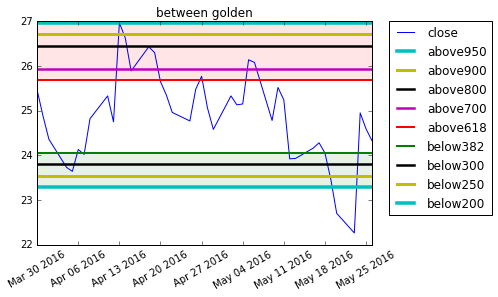

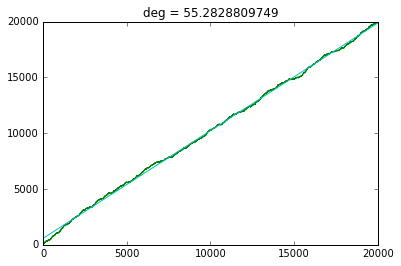

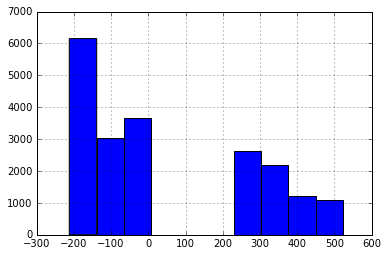

6
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.6725714285714286, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


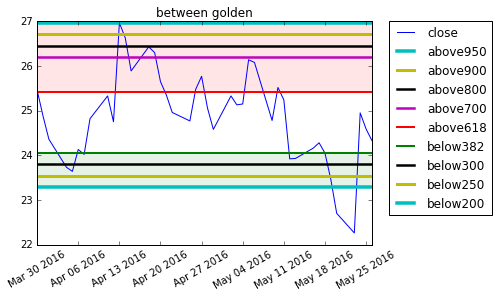

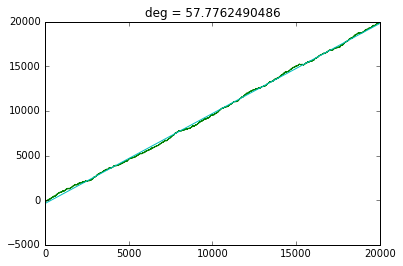

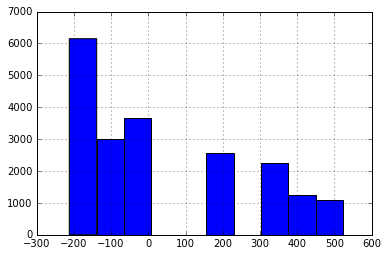

7
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.6725714285714286, 0.7817142857142857, 0.8908571428571428, 0.9454285714285714, 1.0]


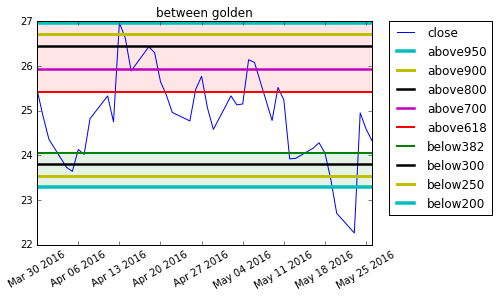

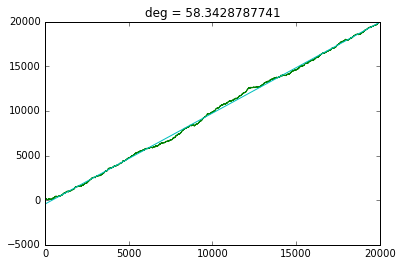

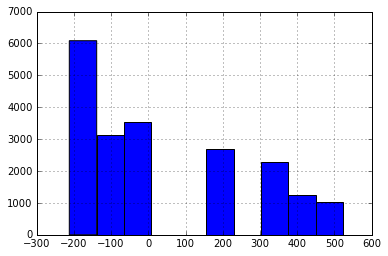

8
[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


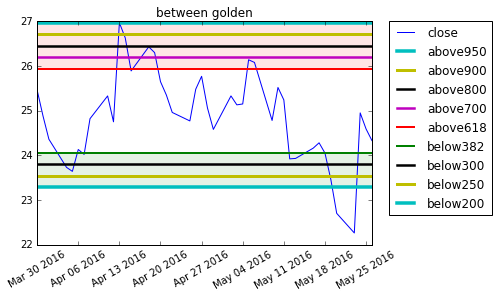

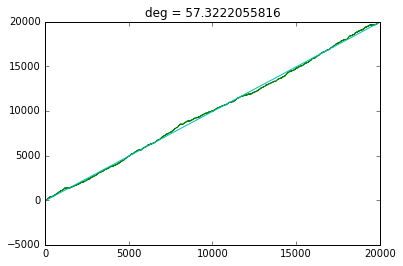

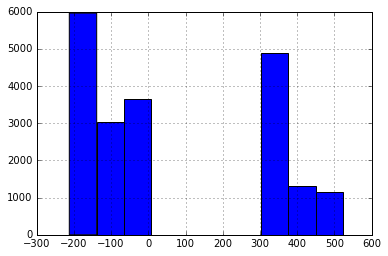

9
[0.10914285714285714, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714, 1.0]


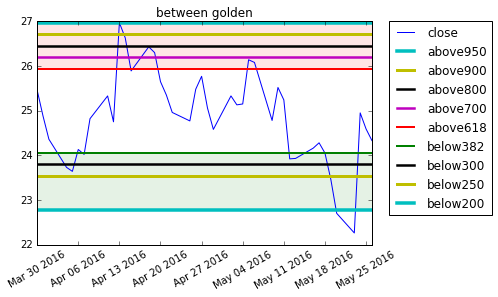

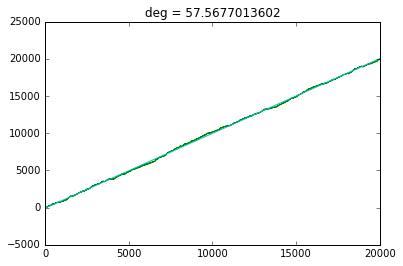

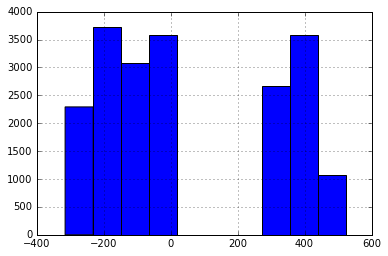

In [31]:
WinLossAlloc.check_golden_mc_result(filter_pd, 0.42)

In [41]:
filter_pd.iloc[4], filter_pd.iloc[4]['keys']

(wl_money_rates                                              2.53341
 wl_rates                                                     0.3608
 sum_moneys                                                   707162
 keys              [0.21828571428571428, 0.27285714285714285, 0.3...
 Name: 1150, dtype: object,
 '[0.21828571428571428, 0.27285714285714285, 0.3274285714285714, 0.382, 0.7271428571428571, 0.7817142857142857, 0.8362857142857143, 0.8908571428571428, 0.9454285714285714]')

在因子的使用上将WinLossAlloc.g_mc_precent结果设置进入

                """
                    make时使用calc_mc_golden的mc结果
                """
                golden = TLineGolden.calc_mc_golden(window_pd, WinLossAlloc.g_mc_precent, WinLossAlloc.g_mc_loss_cnt)
                wl = WinLossAlloc.init_golden_w_full(golden, bp)
                if wl is None:
                    ZLog.debug(factor_name + 'WinLossAlloc.init_golden_w_full w is None')
                    continue
                supports = wl['supports']
                resistances = wl['resistances']

使用之前度量工具的hdf5缓存结果

In [4]:
fn = './data/cache/golden_n6_train_abu'
key = 'golden_n6_train_abu'
orders_pd_train = ZCommonUtil.load_hdf5(fn, key)
orders_pd_train.shape

(42537, 31)

In [5]:
fn = './data/cache/golden_n6_test_abu'
key = 'golden_n6_test_abu'
orders_pd_test = ZCommonUtil.load_hdf5(fn, key)
orders_pd_test.shape

(4837, 31)

In [3]:
from UmpMain import UmpMainClass
from MlFiterGoldenPd import MlFiterGoldenPdClass

In [6]:
train_ump = UmpMainClass(orders_pd_train, MlFiterGoldenPdClass)

all fit order = (40318, 31)
win rate = 0.501091323974
profit_cg.sum() = 248.244833388
win mean = 0.0745953728996 loss_mean = -0.0627537290688 


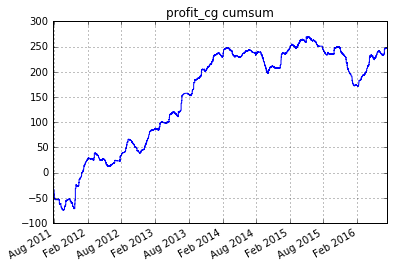

In [7]:
train_ump.show_general()

****‘非均衡胜负收益’带来的必然’非均衡胜负比例‘，目标由’因子‘的能力解决一部分，’机器学习‘提升关键的一部分****

显示前半部分目标效果显然还不错，UmpMainClass负责下半部分的能力

**还是用ml吗？**

1. 用基于TensorFlow的knn，mnn
2. 用其它svm，随机森林等尝试

In [8]:
train_ump.show_knn_tt()

Done!
Accuracy: 0.519593253968
Done!
Accuracy: 0.494295634921
Done!
Accuracy: 0.523561507937
Done!
Accuracy: 0.50744047619
Done!
Accuracy: 0.509672619048
Done!
Accuracy: 0.50744047619
Done!
Accuracy: 0.507936507937
Done!
Accuracy: 0.514384920635
Done!
Accuracy: 0.505333664103


acs mean = 0.510317927924


Done!
Accuracy: 0.513520218308


In [58]:
train_ump.show_mnn_tt()

Optimization Finished!
Accuracy:0.527778
Optimization Finished!
Accuracy:0.513393
Optimization Finished!
Accuracy:0.518601
Optimization Finished!
Accuracy:0.520089
Optimization Finished!
Accuracy:0.520089
Optimization Finished!
Accuracy:0.512897
Optimization Finished!
Accuracy:0.526042
Optimization Finished!
Accuracy:0.518105
Optimization Finished!
Accuracy:0.529149
Optimization Finished!
Accuracy:0.511039
acs mean = 0.519718229771


In [59]:
train_ump.fiter().estimator.svc()
train_ump.fiter().train_test_split_xy()

(40318, 5)
(36286, 5)
(4032, 5)
accuracy = 0.52
precision_score = 0.51
recall_score = 0.59
             precision    recall  f1-score   support

       loss       0.55      0.46      0.50      2077
        win       0.51      0.59      0.55      1955

avg / total       0.53      0.52      0.52      4032



Confusion Matrix  [[ 962 1115]
 [ 803 1152]]
          Predicted
         |  0  |  1  |
         |-----|-----|
       0 | 962 | 1115 |
Actual   |-----|-----|
       1 | 803 | 1152 |
         |-----|-----|


[[10907  9208]
 [ 9622 10581]]


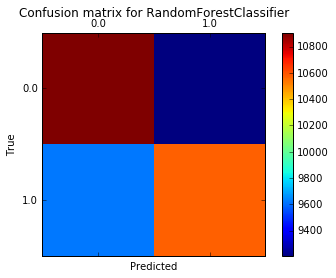

In [65]:
train_ump.fiter().estimator.random_forest_classifier(n_estimators=100)
train_ump.fiter().plot_confusion_matrices()

In [63]:
train_ump.fiter().estimator.adaboost_classifier(n_estimators=200)
train_ump.fiter().cross_val_accuracy_score()

accuracy mean: 0.499702584015


array([ 0.44904538,  0.53136623,  0.52144805,  0.48809524,  0.49702381,
        0.45422972,  0.47283552,  0.53162987,  0.51649715,  0.53485487])

## 结果还是一个叼德行，mnn, svm能到0.52真棒阿

使用gmm-hmm统计分析
    
* 使用gmm从一定范围分类默认40-85需要根据样本数量进行调整，寻找compoent中大于loss阀值的分类分类记做ind
* 返回df index＝compoent_ind 一个compoent中可能有多个ind
* lcs: compoent_ind 中样本总数
* lrs: compoent_ind 中样本loss比例
* lps: compoent_ind 中样本profit sum
* lms: compoent_ind 中样本profit mean

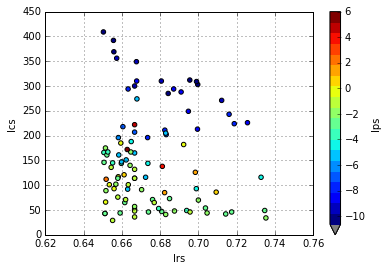

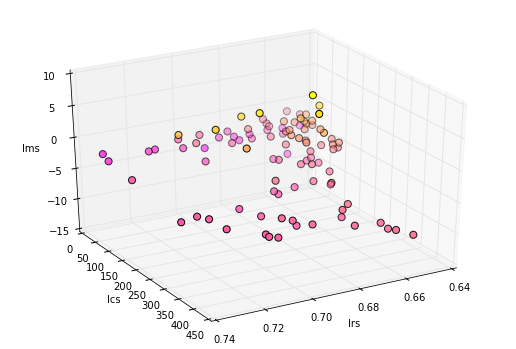

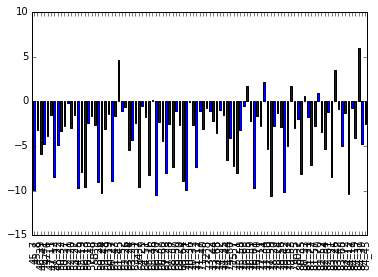

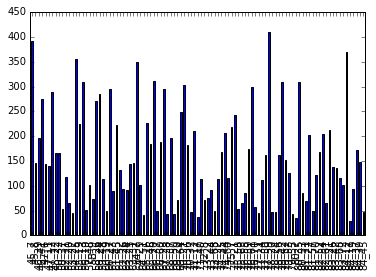

,lcs,lrs,lps,lms
45_7,392.0,0.655612,-9.948956,-0.025380
45_8,145.0,0.655172,-3.175378,-0.022051
46_39,196.0,0.658163,-5.858433,-0.029890
46_41,274.0,0.667883,-4.827420,-0.017618
47_6,144.0,0.659722,-3.877253,-0.027305
47_11,140.0,0.664286,-1.535189,-0.010966
47_12,288.0,0.690972,-8.414375,-0.029217
48_22,165.0,0.666667,-4.916437,-0.030162
50_32,166.0,0.650602,-3.319263,-0.019996
50_37,54.0,0.703704,-2.724255,-0.050449


In [9]:
train_ump.gmm_component_filter()

In [10]:
# fn = './data/cache/train_ump_abu'
# ZCommonUtil.dump_pickle(train_ump, fn)
# train_ump = ZCommonUtil.load_pickle(fn)

In [12]:
train_ump.cprs.loc[train_ump.cprs.lcs.argmax()]

lcs    409.000000
lrs      0.650367
lps    -10.629263
lms     -0.026052
Name: 77_59, dtype: float64

找出来的就是如下类似的20， 27分类

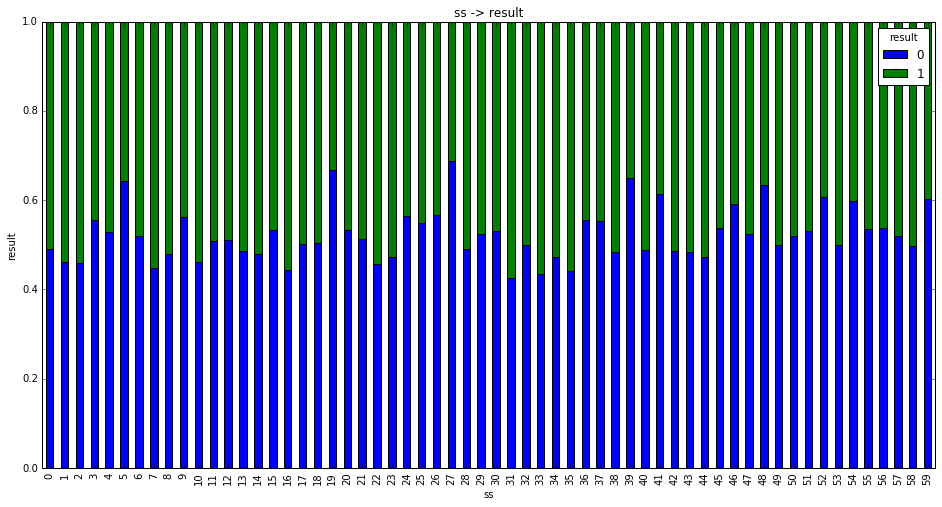

In [13]:
train_ump.show_parse_rt(train_ump.rts.values()[13])

**寻找全局最优**
      
     如下min目标improved

In [86]:
    def brust_min(self):
        """
        全局最优
        :return:
        """
        cprs = self.cprs
        optv = sco.brute(self.min_func_improved, ((round(cprs['lps'].min(), 2), 0, 0.5), (round(cprs['lms'].min(), 2),
                                                                                          round(cprs['lms'].max(), 3),
                                                                                          0.01),
                                                  (round(cprs['lrs'].min(), 2), round(cprs['lrs'].max(), 2), 0.1)),
                         finish=None)
        return optv

    def sco_min(self, guess):
        """
        局部最优借
        :param guess:
        :return:
        """
        cprs = self.cprs
        bnds = ((round(cprs['lps'].min(), 3), round(cprs['lps'].max(), 3)),
                (round(cprs['lms'].min(), 3), round(cprs['lms'].max(), 3)),
                (round(cprs['lrs'].min(), 3), round(cprs['lrs'].max(), 3)))

        optv = sco.minimize(self.min_func_improved, guess, method='BFGS',
                            bounds=bnds)
        return optv

    def min_func(self, lpmr):
        cprs = self.cprs
        nts = self.nts

        llps = cprs[(cprs['lps'] <= lpmr[0]) & (cprs['lms'] <= lpmr[1]) & (cprs['lrs'] >= lpmr[2])]

        nts_pd = pd.DataFrame()
        for nk in llps.index:
            nts_pd = nts_pd.append(nts[nk])
        if nts_pd.empty:
            return np.array([0.0001, 0])
        nts_pd = nts_pd.drop_duplicates(subset='ind', keep='last')

        num = nts_pd.shape[0]
        loss_rate = nts_pd.result.value_counts()[0] / nts_pd.result.value_counts().sum()
        win_rate = nts_pd.result.value_counts()[1] / nts_pd.result.value_counts().sum()
        improved = (nts_pd.shape[0] / self.fiter.order_has_ret.shape[0]) * (loss_rate - win_rate)
        # print improved
        return np.array([improved, num])

    def min_func_improved(self, lpmr):
        """
            求最大提高，min负数
        """
        return -self.min_func(lpmr)[0]

In [14]:
train_ump.brust_min()

array([-0.63,  0.  ,  0.65])

再次带入求局部优化

In [16]:
guess = [-0.63,  0.  ,  0.65]
train_ump.sco_min(guess)

      fun: -0.014063197579245
 hess_inv: array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])
      jac: array([ 0.,  0.,  0.])
  message: 'Optimization terminated successfully.'
     nfev: 5
      nit: 0
     njev: 1
   status: 0
  success: True
        x: array([-0.63,  0.  ,  0.65])

In [91]:
pd.qcut(train_ump.cprs['lps'], 10).value_counts()

(-0.21, 6.0137]      10
(-1.0954, -0.21]     10
(-1.614, -1.0954]    10
(-2.456, -1.614]     10
(-3.81, -2.845]      10
(-5.204, -3.81]      10
(-7.931, -5.204]     10
(-9.561, -7.931]     10
[-10.629, -9.561]    10
(-2.845, -2.456]      9
Name: lps, dtype: int64

*筛选出符合最优的llps*

In [18]:
llps = train_ump.cprs[(train_ump.cprs['lps'] <= -0.63) & (train_ump.cprs['lms'] <= -0.00 )& (train_ump.cprs['lrs'] >=0.65)]
llps

,lcs,lrs,lps,lms
45_7,392.0,0.655612,-9.948956,-0.025380
45_8,145.0,0.655172,-3.175378,-0.022051
46_39,196.0,0.658163,-5.858433,-0.029890
46_41,274.0,0.667883,-4.827420,-0.017618
47_6,144.0,0.659722,-3.877253,-0.027305
47_11,140.0,0.664286,-1.535189,-0.010966
47_12,288.0,0.690972,-8.414375,-0.029217
48_22,165.0,0.666667,-4.916437,-0.030162
50_32,166.0,0.650602,-3.319263,-0.019996
50_37,54.0,0.703704,-2.724255,-0.050449


如下显现这些的负作用力

1. loss_rate稍小。
2. 预期胜率提升0.014

nts_pd.shape = (2085, 9)
nts_pd loss rate = 0.635971223022
improved rate = 0.0140631975792
predict win rate = 0.515154521554


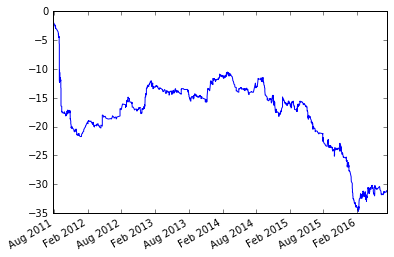

In [19]:
train_ump.choose_cprs_component(llps)

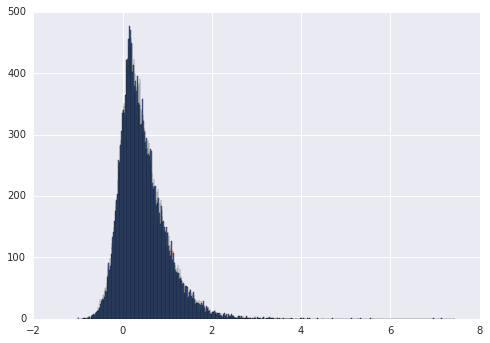

atr_std show hist and qcuts
(1.125, 7.425]          4254
(0.826, 1.125]          4254
(0.48, 0.629]           4254
(0.246, 0.357]          4254
(0.15, 0.246]           4254
(-0.0945, 0.0455]       4254
[-1.000781, -0.0945]    4254
(0.629, 0.826]          4253
(0.357, 0.48]           4253
(0.0455, 0.15]          4253
Name: atr_std, dtype: int64


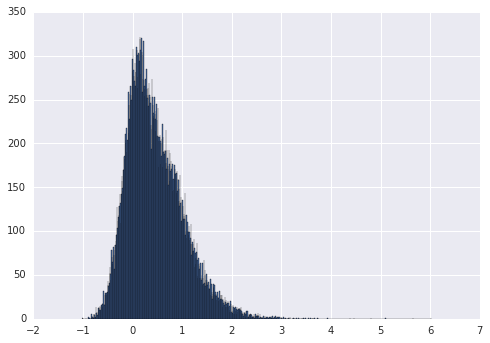

wave_score1 show hist and qcuts
(1.203, 6.0266]      4254
(0.903, 1.203]       4254
(0.513, 0.693]       4254
(0.227, 0.361]       4254
(0.108, 0.227]       4254
(-0.175, -0.0154]    4254
[-1.0169, -0.175]    4254
(0.693, 0.903]       4253
(0.361, 0.513]       4253
(-0.0154, 0.108]     4253
Name: wave_score1, dtype: int64


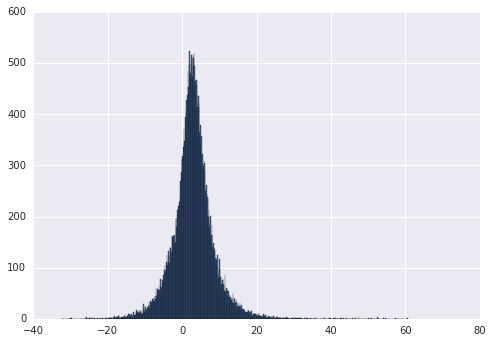

deg_windowPd show hist and qcuts
(9.0994, 60.638]     4254
(6.479, 9.0994]      4254
(3.83, 4.949]        4254
(1.933, 2.871]       4254
(0.867, 1.933]       4254
(-3.293, -0.636]     4254
[-32.109, -3.293]    4254
(4.949, 6.479]       4253
(2.871, 3.83]        4253
(-0.636, 0.867]      4253
Name: deg_windowPd, dtype: int64


In [165]:
import MlFiterBinsCs
MlFiterBinsCs.show_orders_hist(orders_pd_train, s_list = ['atr_std','wave_score1', 'deg_windowPd'])

**看看这个有73%失败的分类列，发现内在的隐含意义**

deg_hisWindowPd， deg_windowPd， deg_60WindowPd都负的很大
atr_std和wave_score1似乎没什么特点结合上面的📊观测

In [20]:
train_ump.nts['80_7']

,result,atr_std,deg_hisWindowPd,deg_windowPd,deg_60WindowPd,wave_score1,ind,ss,profit
2015-08-31,0,0.650282,-35.452195,-25.828609,-32.302257,1.883735,727,7,-0.227642
2015-11-03,0,0.422939,-26.183546,-15.574519,-27.438591,1.328020,1738,7,-0.272727
2015-12-08,1,0.673545,-35.585717,-23.648320,-30.332836,1.860030,2660,7,0.293307
2016-02-05,0,0.084203,-43.172617,-15.968829,-32.833797,1.652111,3897,7,-0.031447
2016-02-16,1,0.315144,-40.234372,-15.135073,-27.419828,1.091432,4023,7,0.179210
2016-02-18,1,0.416464,-26.453663,-25.682009,-27.742160,0.919076,4042,7,0.643172
2016-02-19,0,0.135057,-49.953687,-29.732415,-39.398126,0.405540,4052,7,-0.745763
2016-02-22,1,0.562268,-31.770624,-25.725051,-34.475286,1.106047,4077,7,0.526995
2016-02-23,1,0.778002,-43.090522,-30.004777,-36.509807,1.727595,4119,7,0.434034
2016-03-01,1,0.656723,-41.755832,-15.389855,-32.440863,1.002845,4200,7,0.022936


交互测试下效果


**测试集没有开启因子优化的结果0.497， 根据数据显示可以优化到0.512吗？**

all fit order = (4588, 31)
win rate = 0.497820401046
profit_cg.sum() = 23.8727798282
win mean = 0.0724627453005 loss_mean = -0.0615429338615 


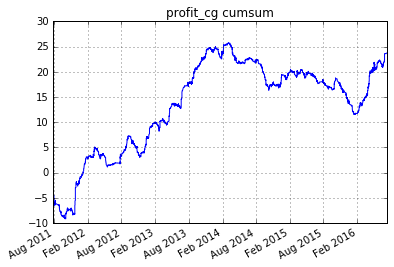

In [135]:
StatsOrdersClass(orders_pd_test, MlFiterGoldenPdClass).show_general()

**将所有符合要求的gmm clf序列化，因子回测优化使用**

In [190]:
train_ump.dump_clf(llps)

使用切割测试集开启因子优化回测数优化：


        use_last_test=True
        BuyGoldenFactor.g_enable_fiter = True

In [7]:
import BuyGoldenFactor
from BuyGoldenFactor import BuyGoldenFactorClass
import MetricsManger
from MetricsManger import metrics_rsc
from FactorMetrics import METRICSTYPE

BuyGoldenFactor.g_enable_fiter = True
buy_factors = [{'XD': 42, 'class': BuyGoldenFactorClass, 'draw': True}]
out, orders_pd_test_enable_fiter = MetricsManger.make_metrics_rsc_mul_symbol_grid(buy_factors, n_folds=6, 
    score_type=METRICSTYPE.SYSMBOL_R_SCORES_GOLDEN.value, ret_cnt_need=0, train_test_split=False, 
    use_last_test=True, force_one_process=False)

In [180]:
# fn = './data/cache/golden_n6_enable_fiter_best1_abu'
# key = 'golden_n6_enable_fiter_best1_abu'
# ZCommonUtil.dump_hdf5(orders_pd_test_enable_fiter, key, fn)
# orders_pd_test_enable_fiter = ZCommonUtil.load_hdf5(fn, key)

In [141]:
orders_pd_test_enable_fiter.shape

(4564, 31)

all fit order = (4335, 31)
win rate = 0.504498269896
profit_cg.sum() = 26.3090428828
win mean = 0.0691880572237 loss_mean = -0.0582673178493 


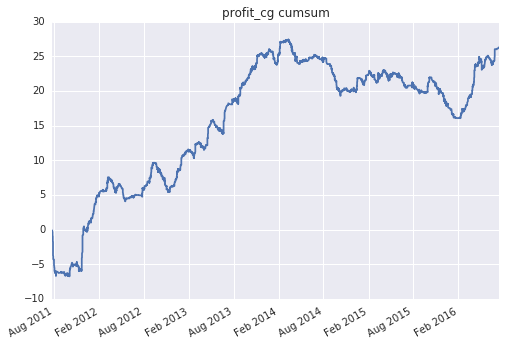

In [142]:
StatsOrdersClass(orders_pd_test_enable_fiter, MlFiterGoldenPdClass).show_general()

win rate提高0.007没有达到预期improved rate = 0.014

In [145]:
0.504 - 0.497, 26.3 - 23.8

(0.007000000000000006, 2.5)

In [149]:
import TradeProxy
reload(TradeProxy)
unsame_order = TradeProxy.find_unsame_in_2orders(orders_pd_test, orders_pd_test_enable_fiter)

In [151]:
unsame_order = unsame_order[unsame_order.result <> 0]
unsame_order.shape

(253, 31)

之前预测失败率0.635，实际筛出来的失败率是0.616 其实还不错

unsame_order loss rate = 0.616600790514


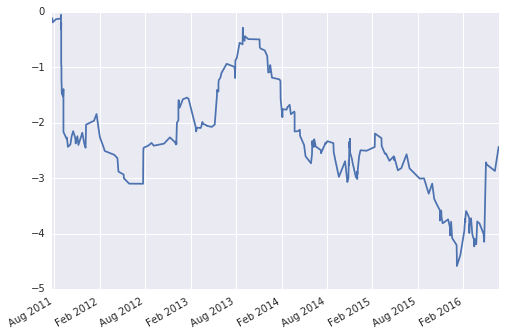

In [172]:
pd.options.display.max_columns = 100
unsame_order.sort_values('buy Date').profit_cg.cumsum().plot()

xt = unsame_order.result.value_counts()
ZLog.info('unsame_order loss rate = ' + str(float(xt[-1]) / xt.sum()))

**看下有很多收益超过20%的单子被block掉了，虽然也有很多损失超过20%的单子说明**

符合分类列的特征还有很大概率产生大单子

解决方案：gmm分类中找损失超过多少阀值的类似优先筛选或者组合权重筛选

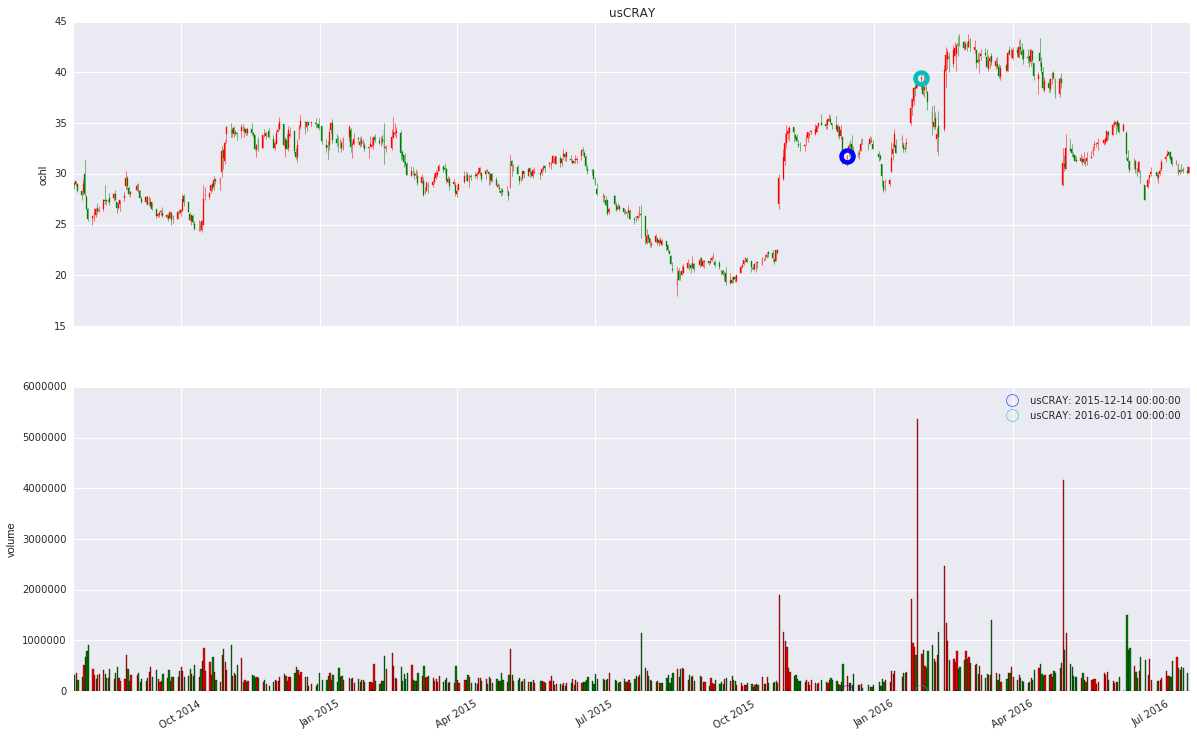

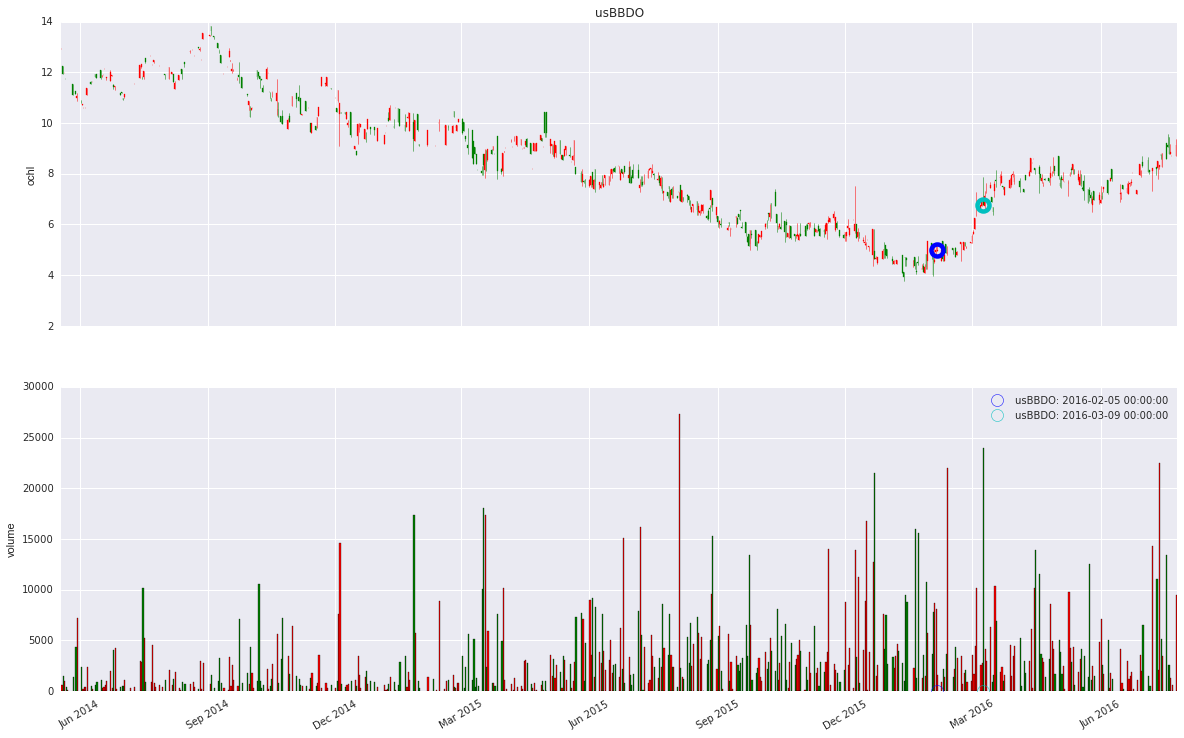

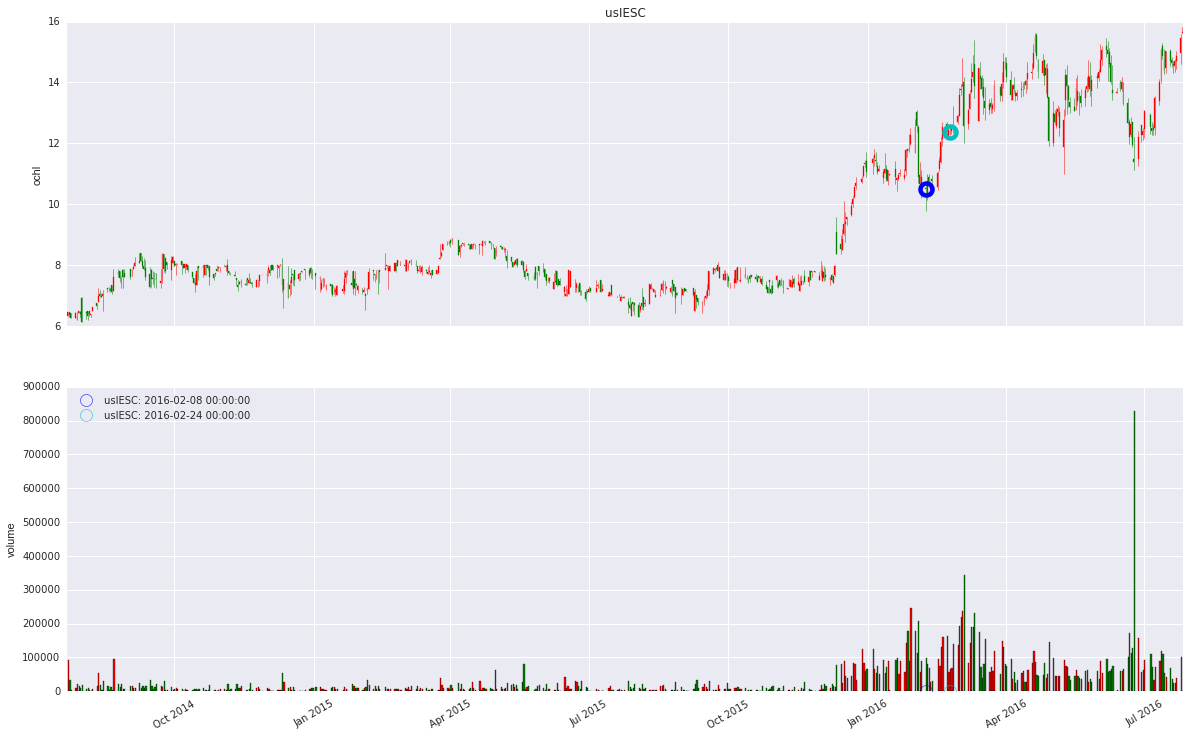

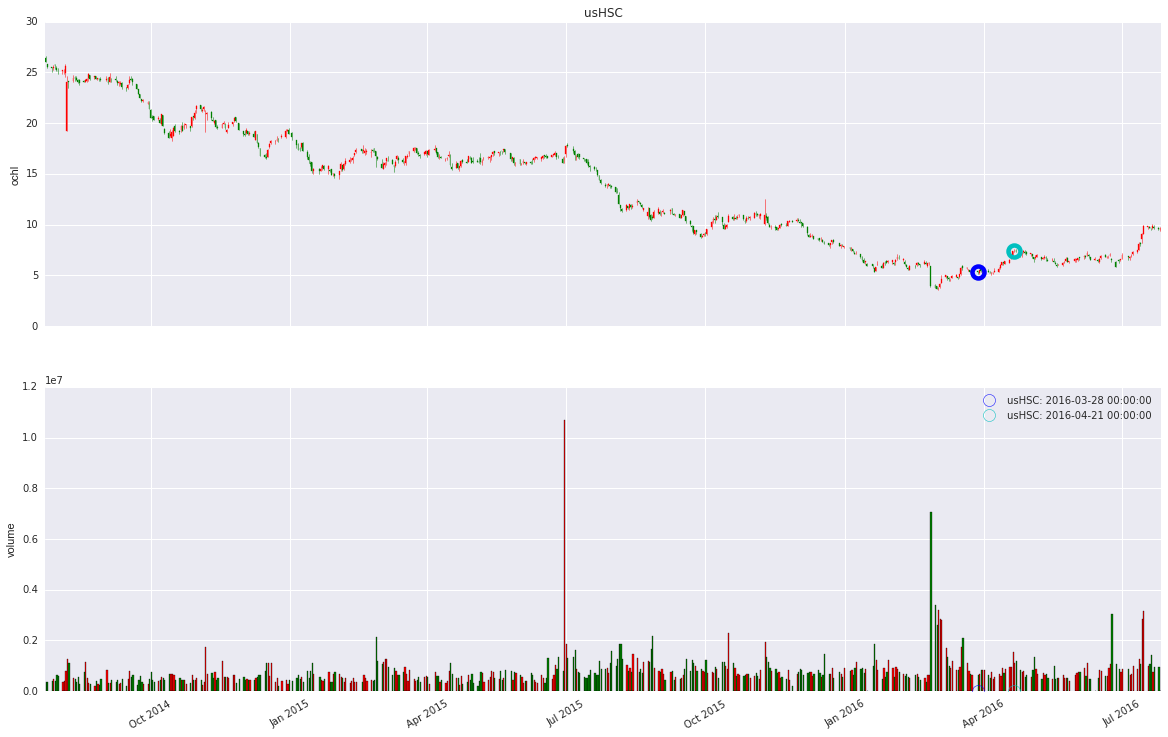

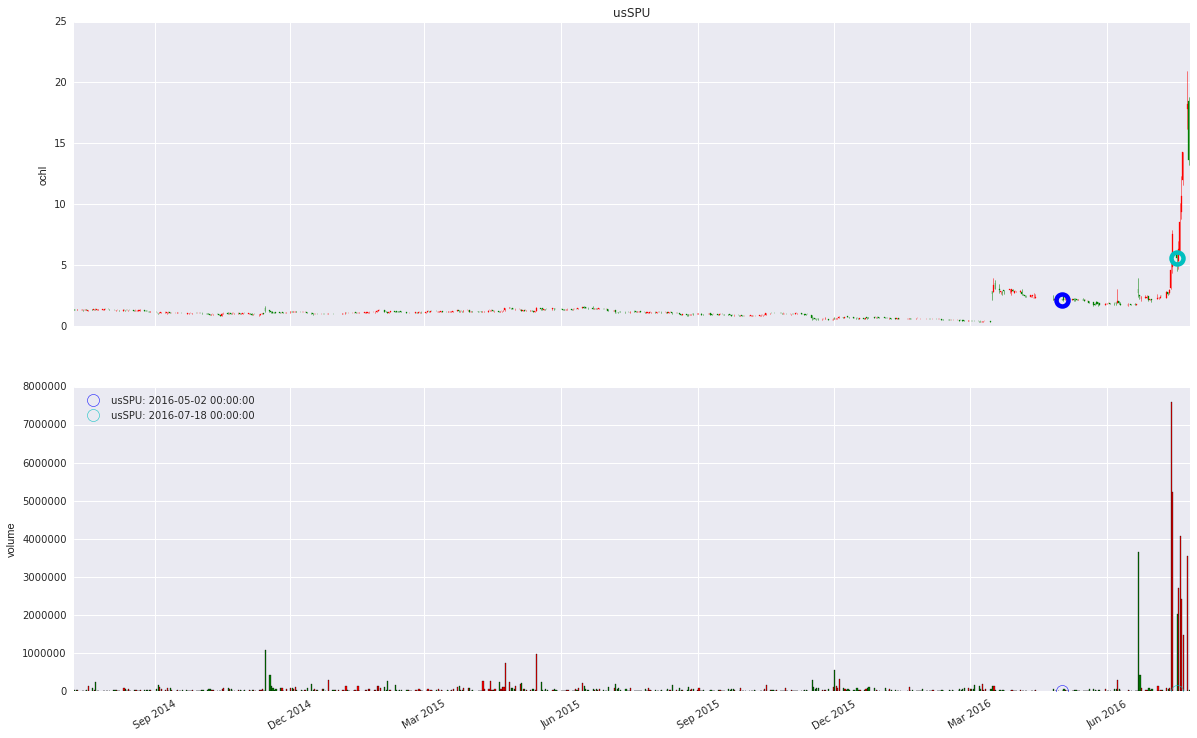

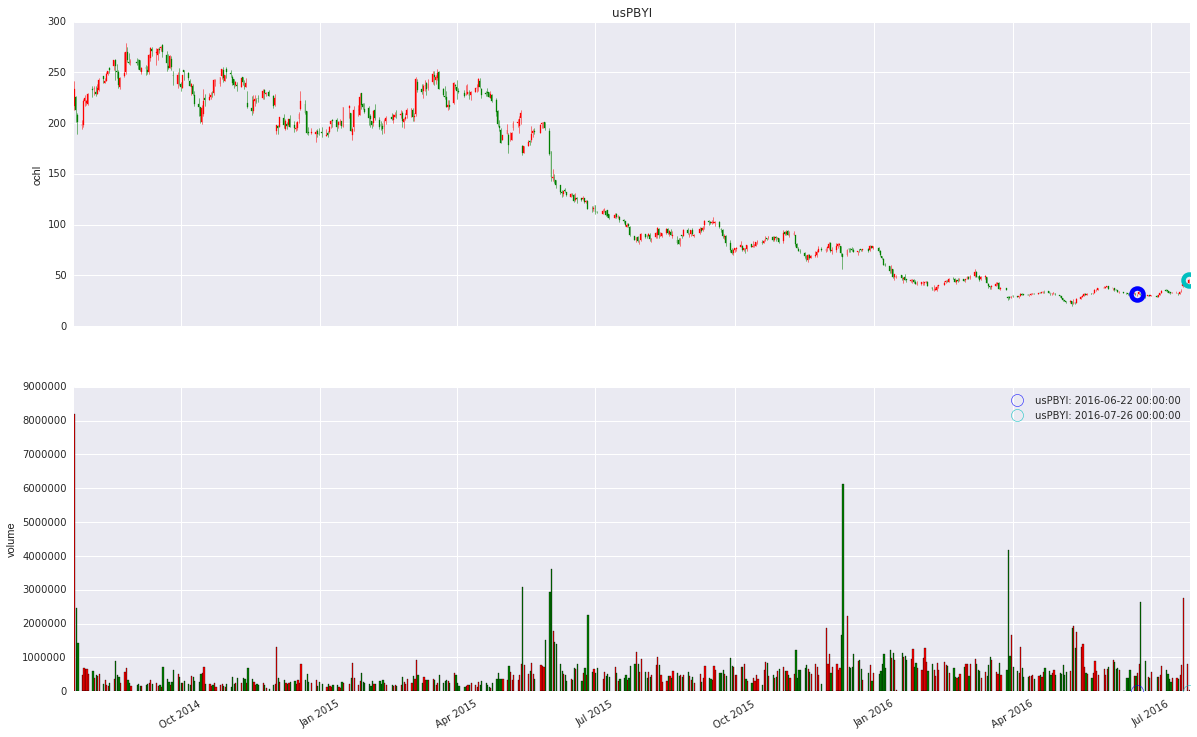

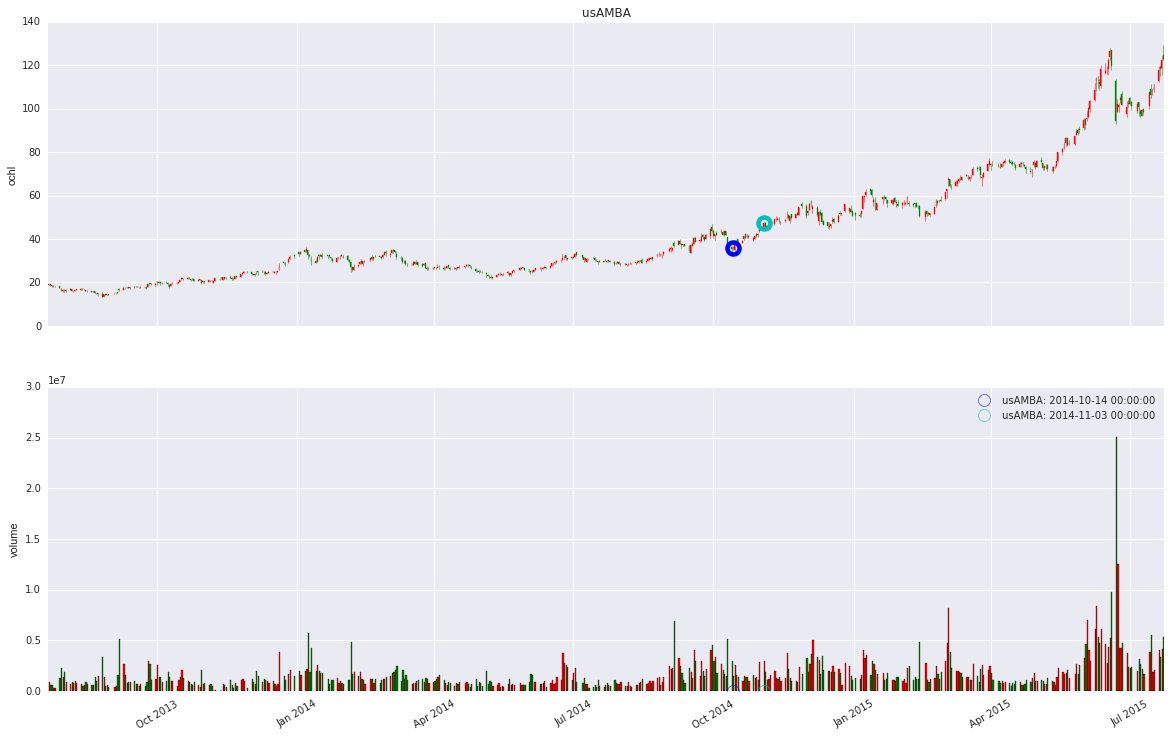

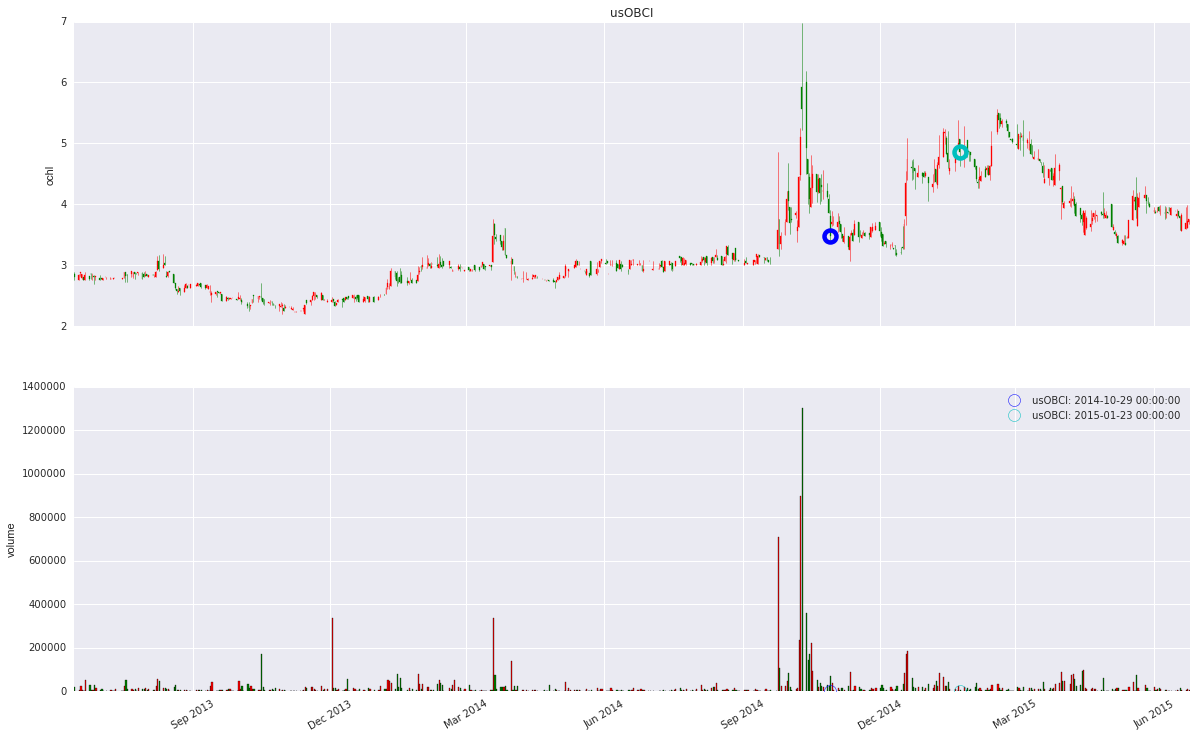

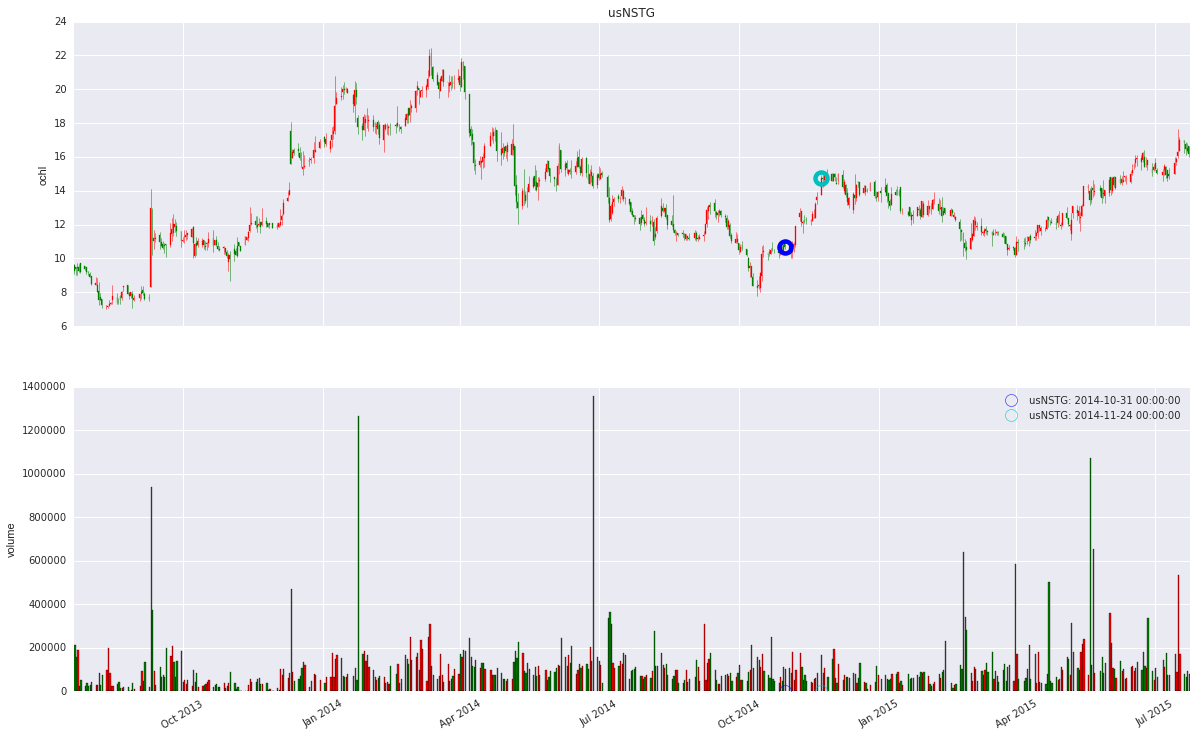

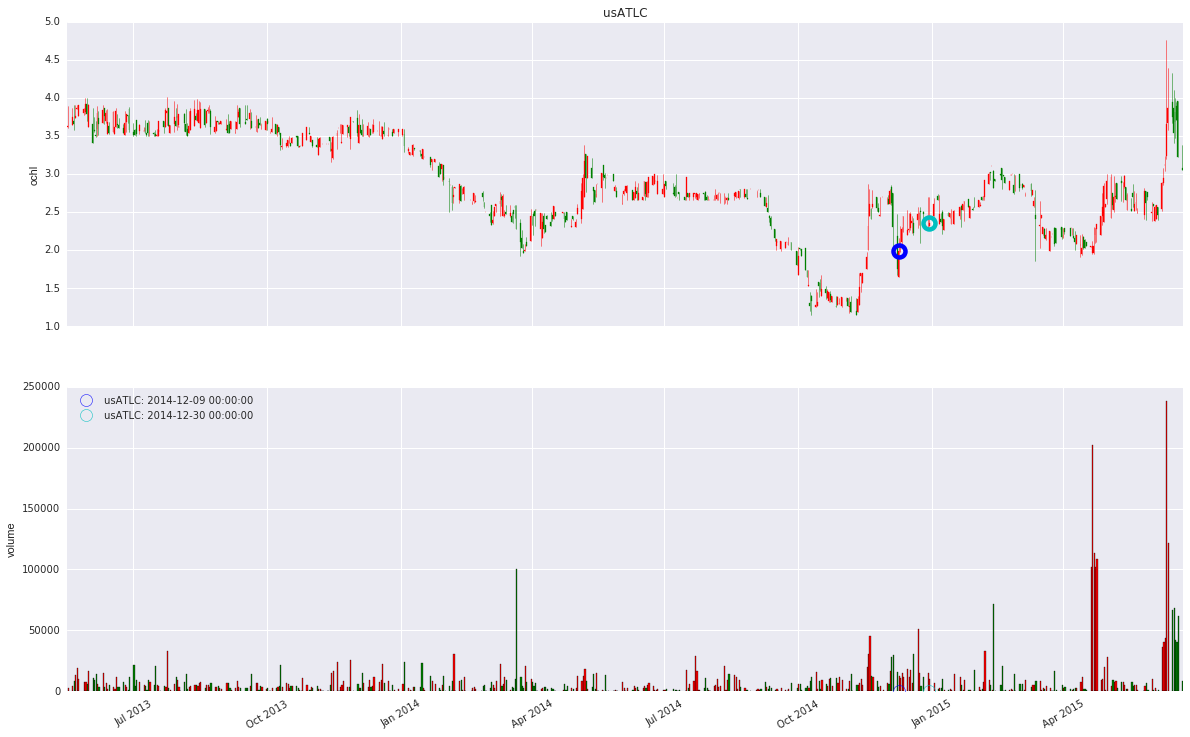

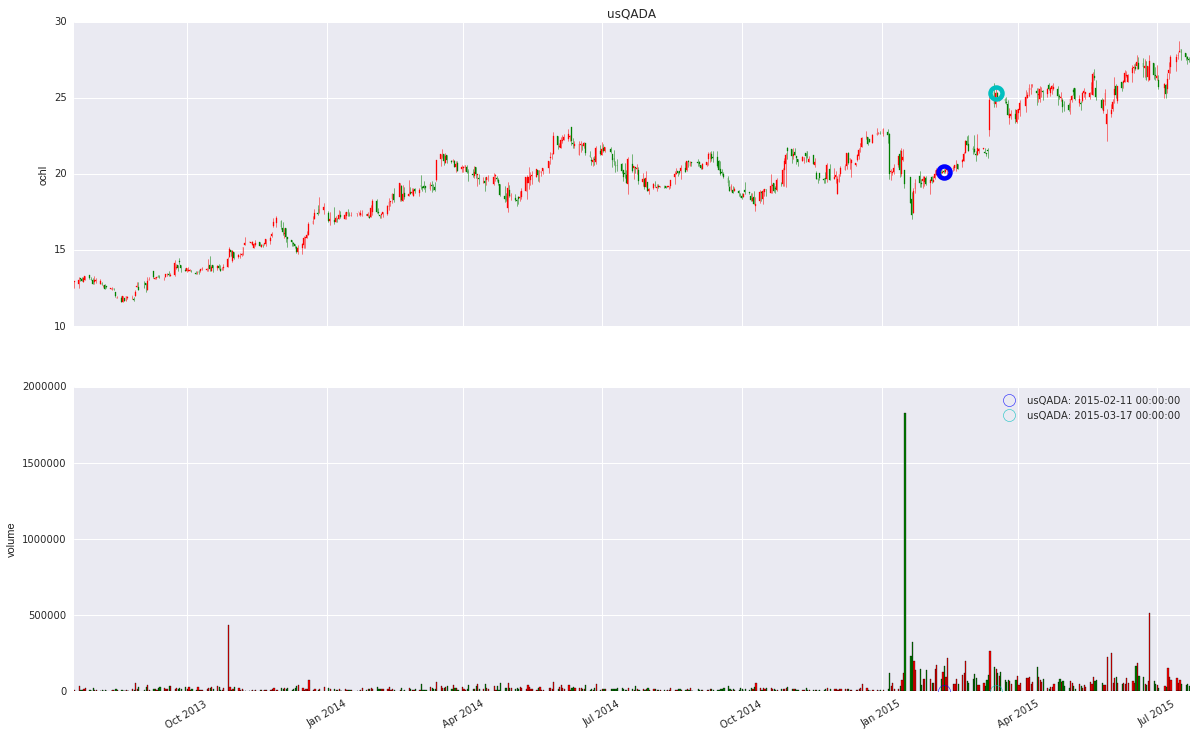

Timestamp('2015-06-18 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-06-18 00:00:00') is not in list
Timestamp('2015-06-26 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-06-26 00:00:00') is not in list


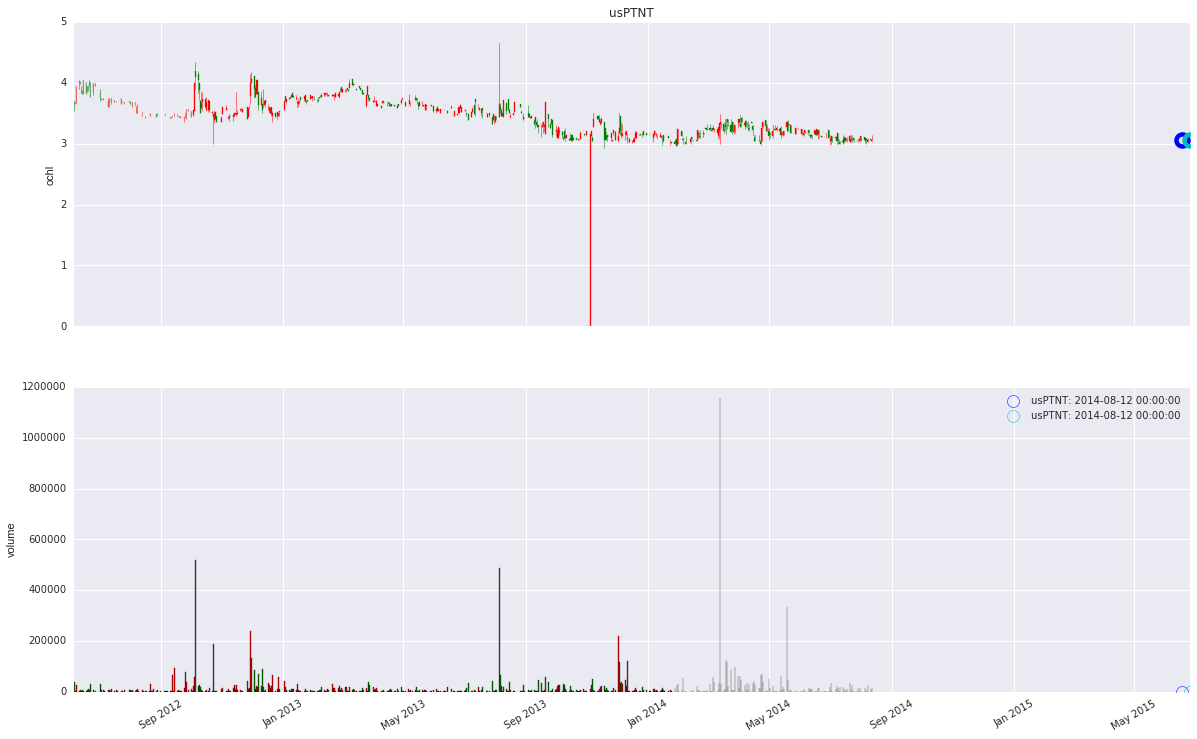

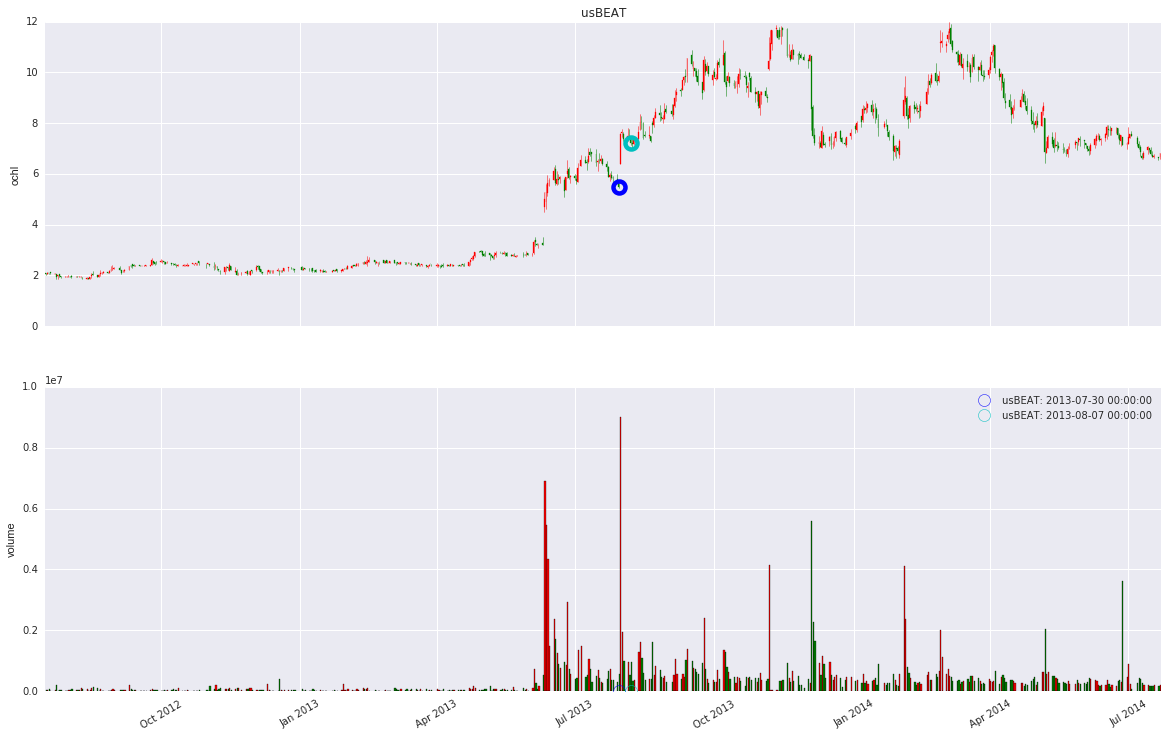

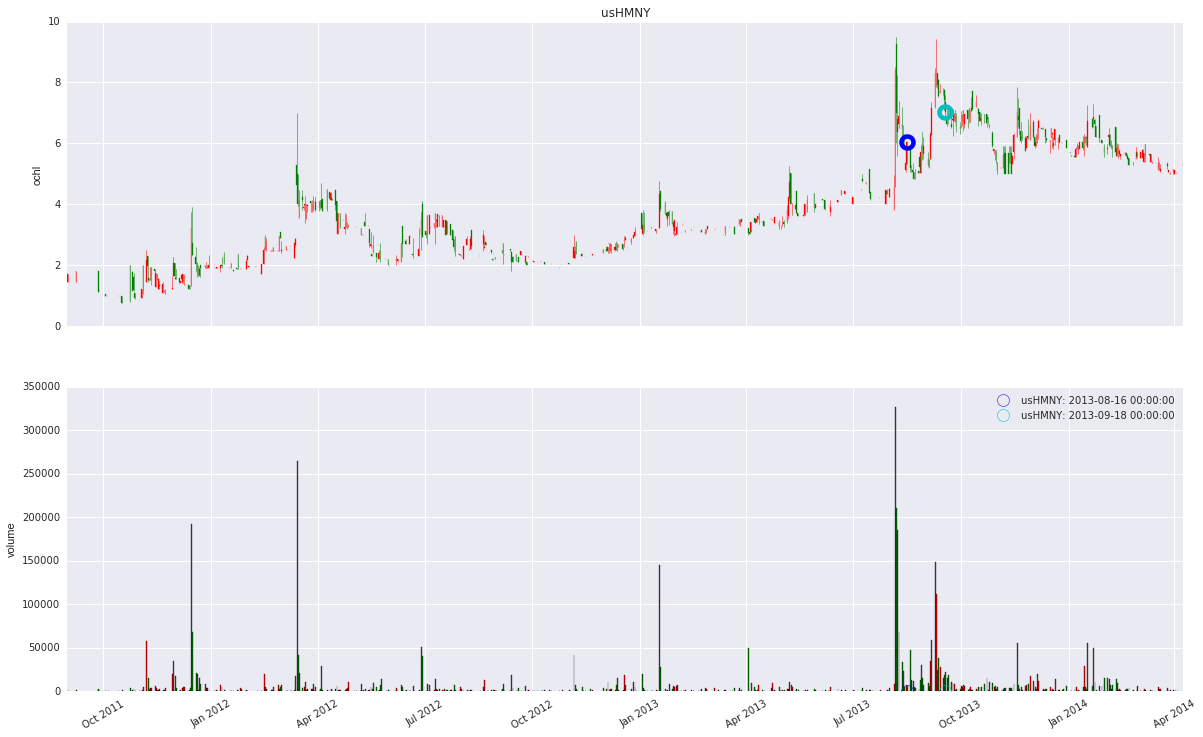

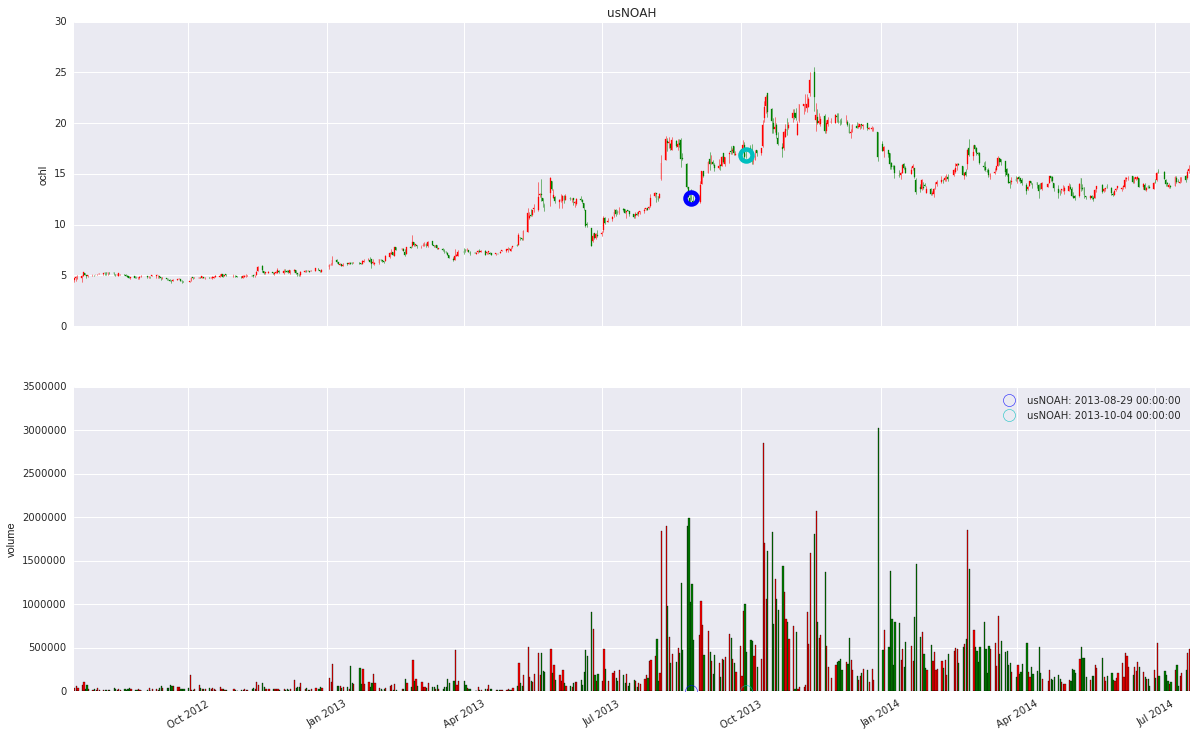

Timestamp('2014-06-04 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2014-06-04 00:00:00') is not in list
Timestamp('2014-06-13 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2014-06-13 00:00:00') is not in list


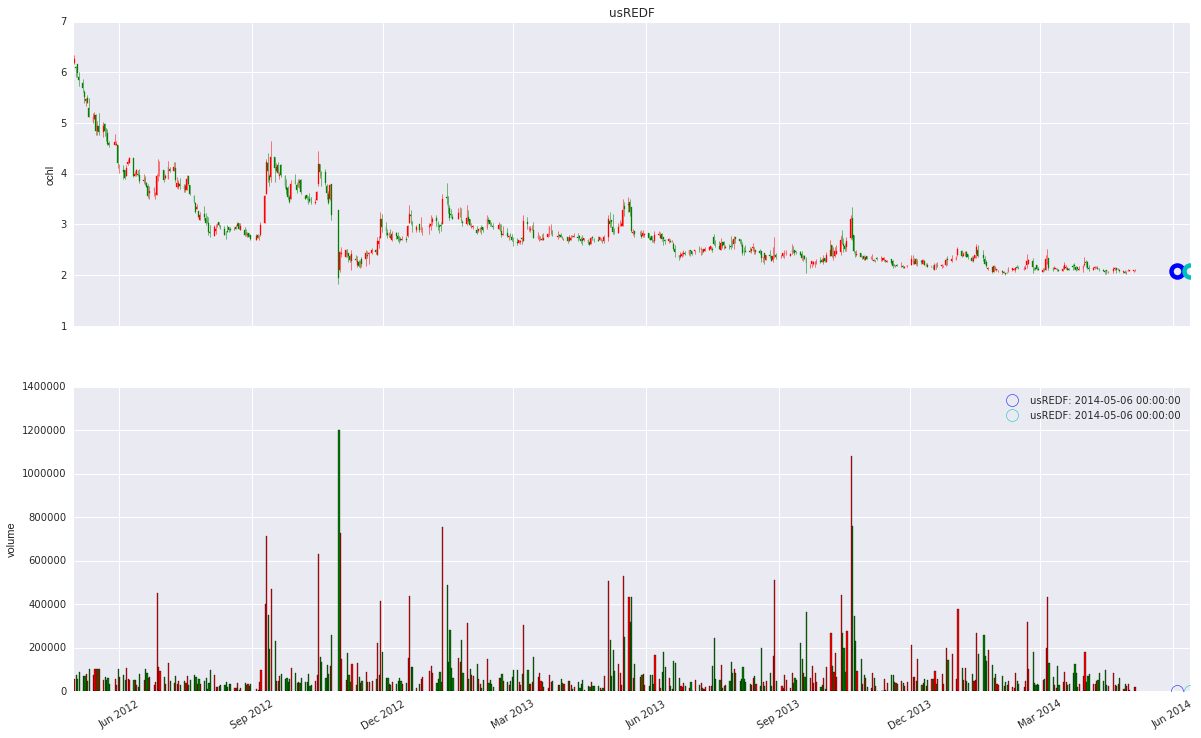

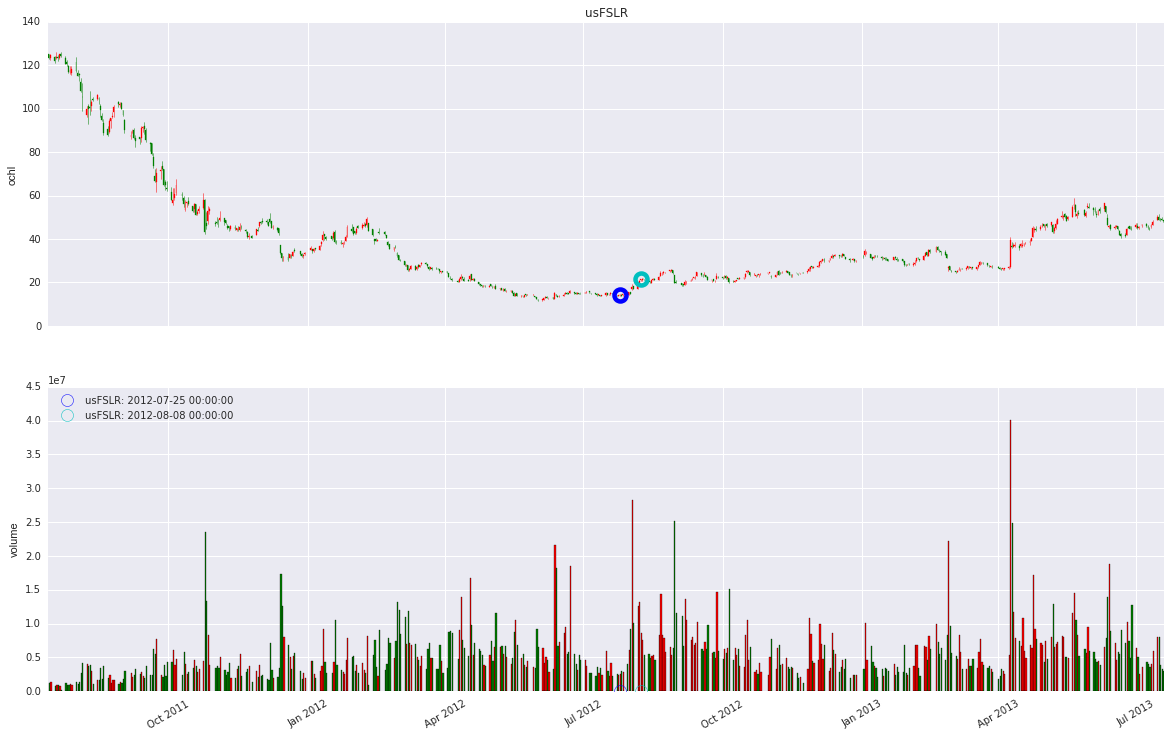

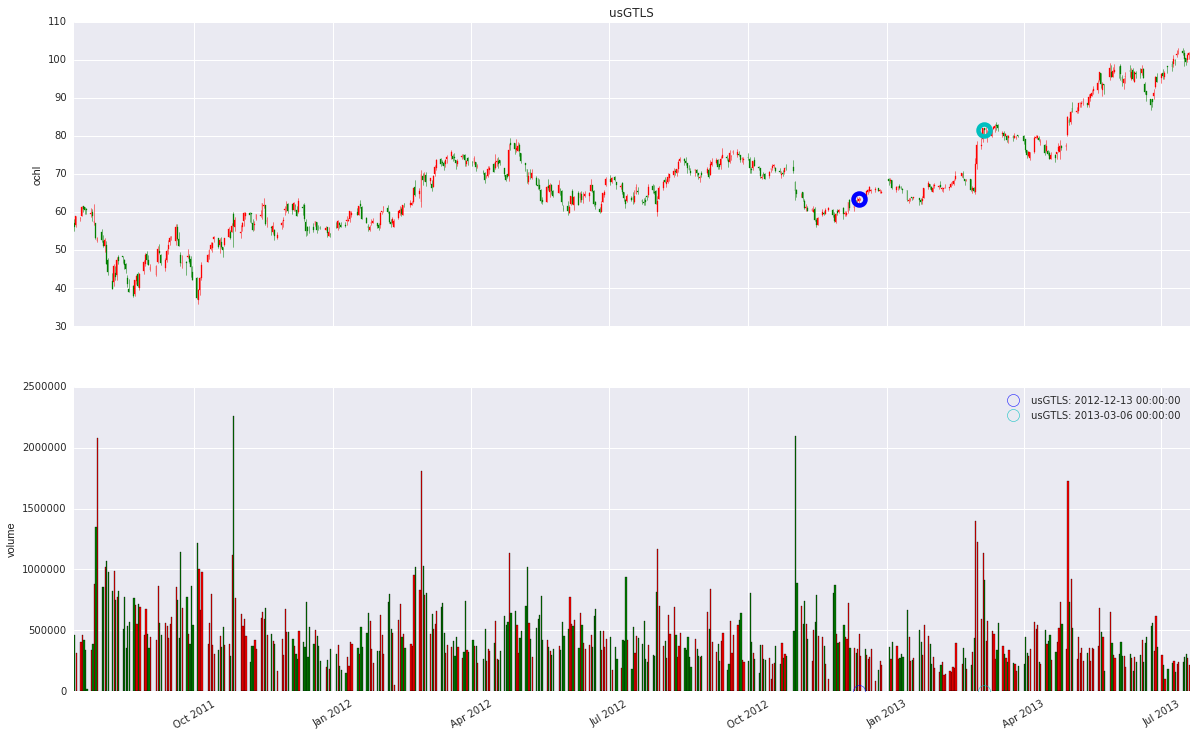

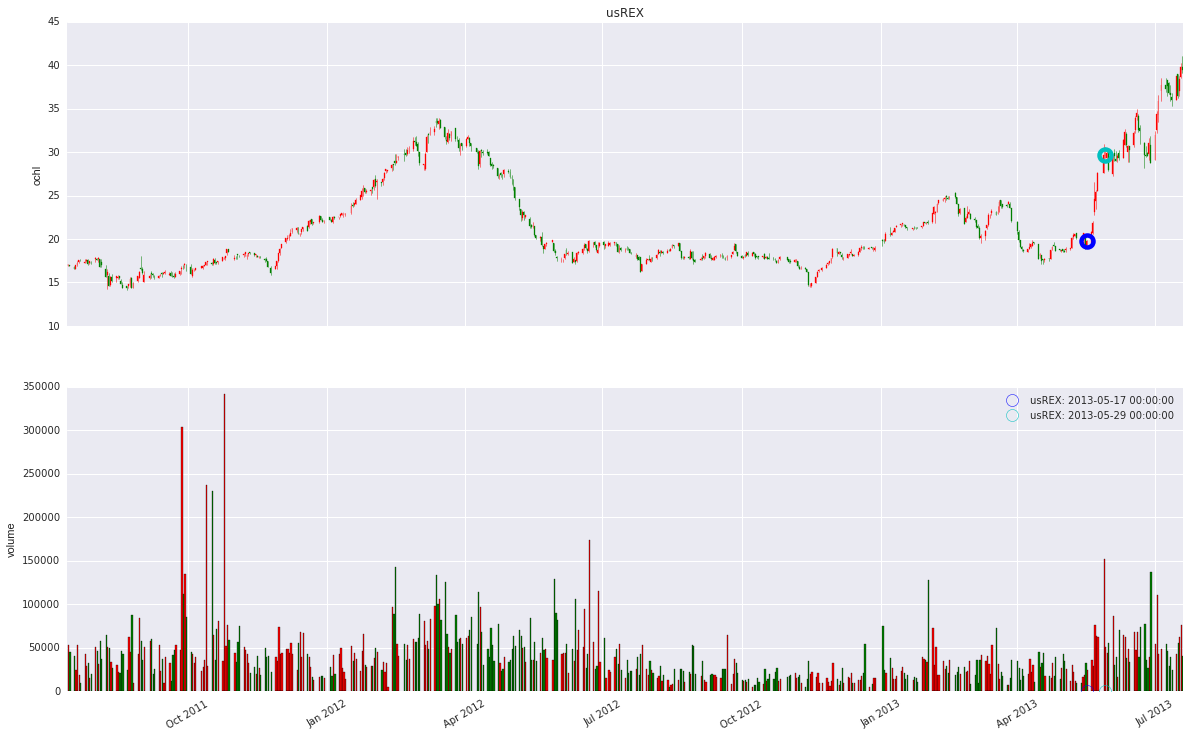

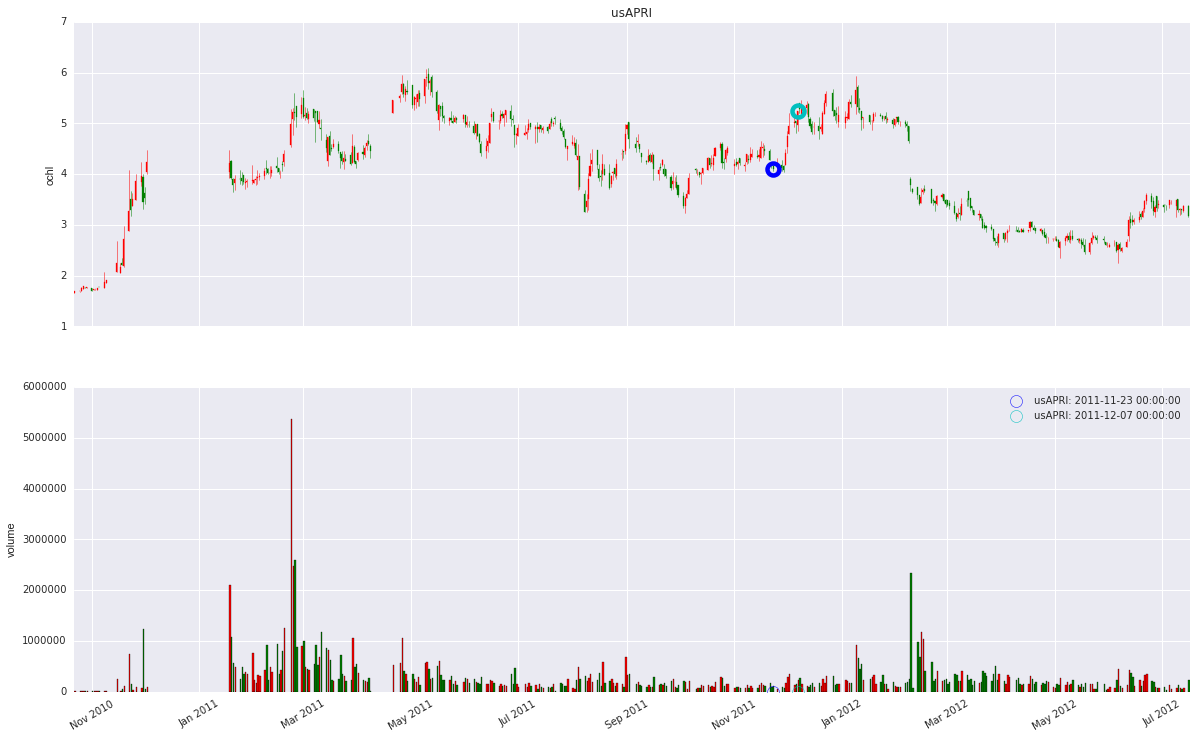

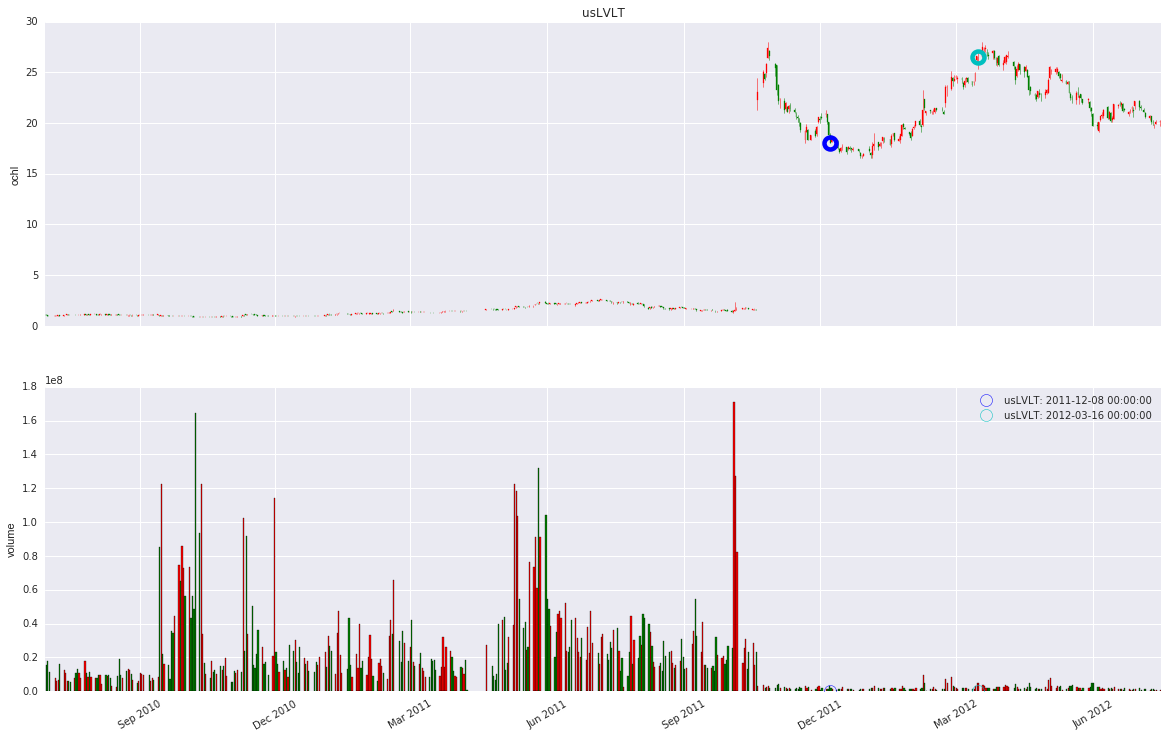

In [178]:
import MarketDrawer
MarketDrawer.plot_candle_from_order(unsame_order[unsame_order.profit_cg > 0.20])

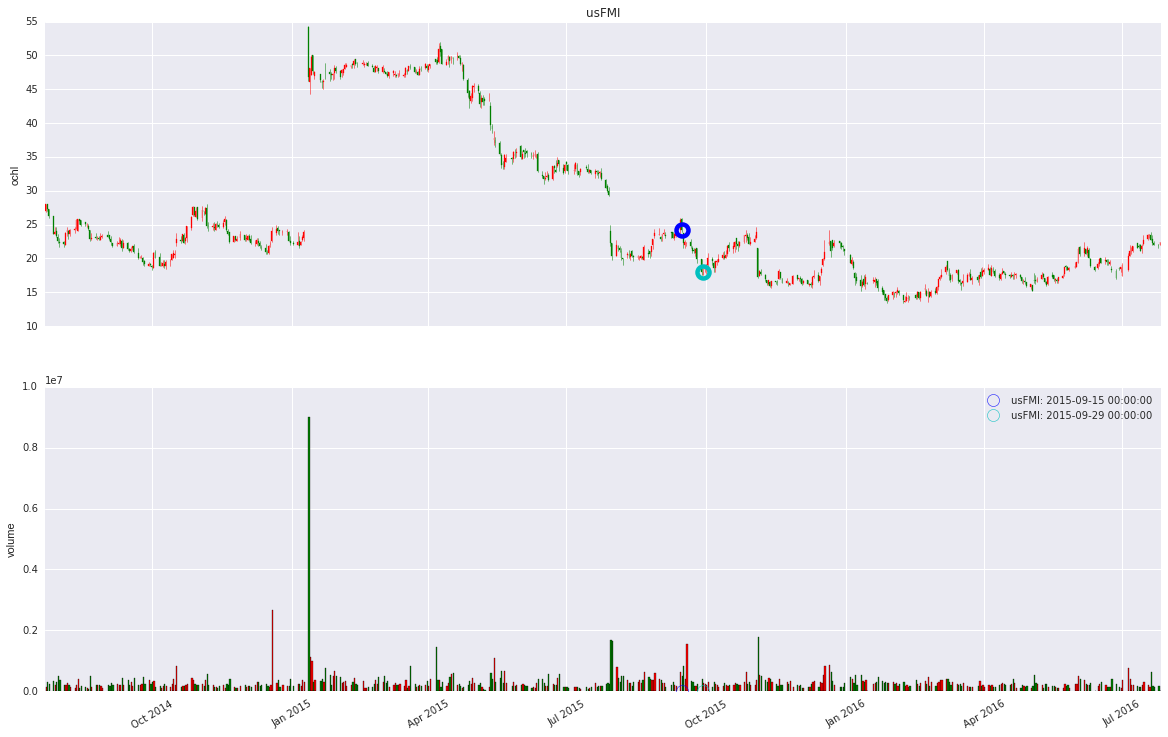

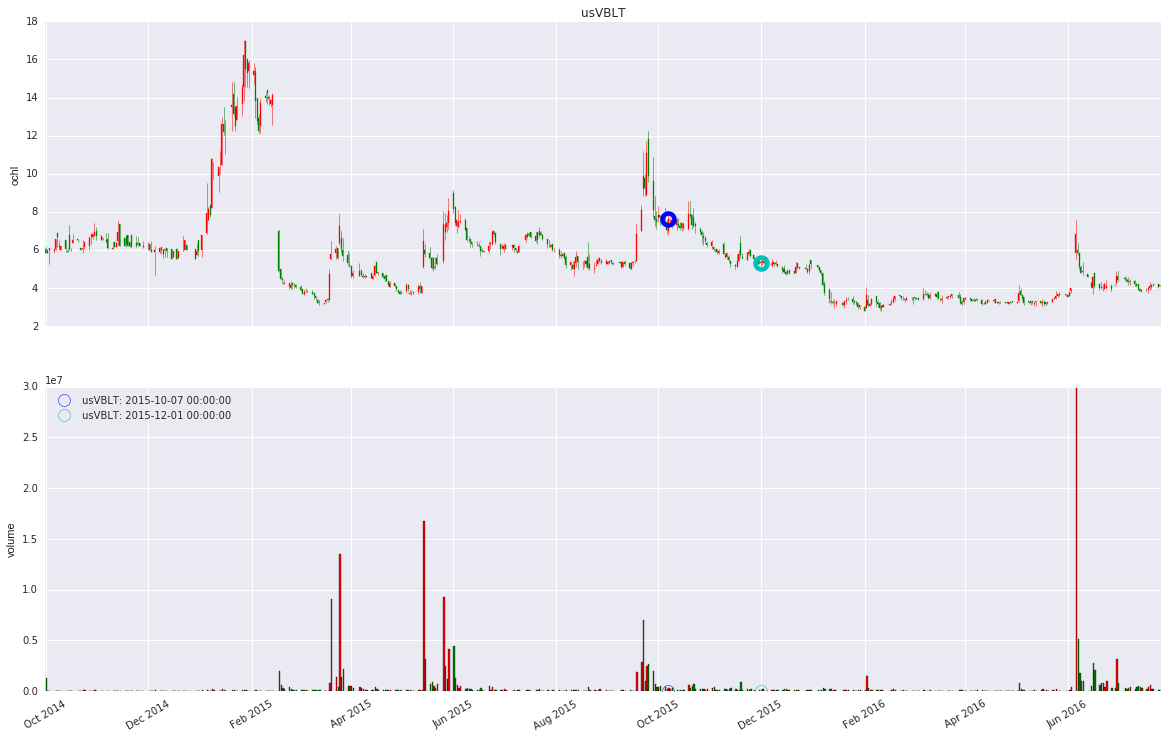

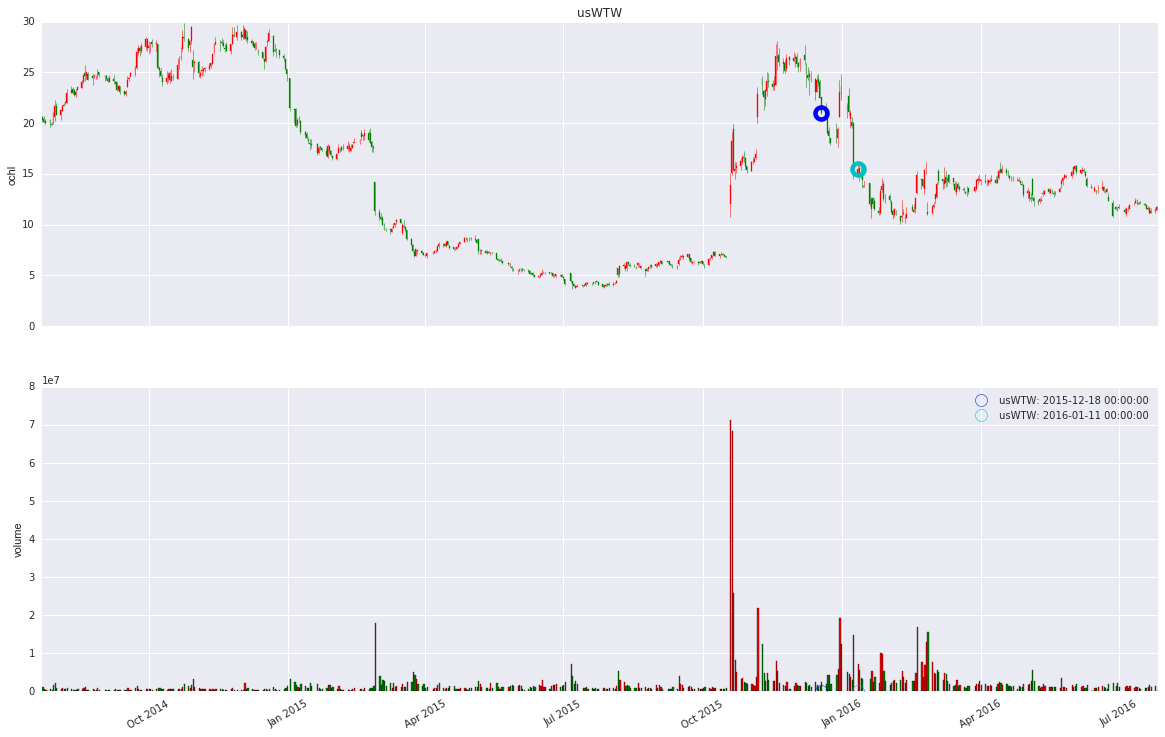

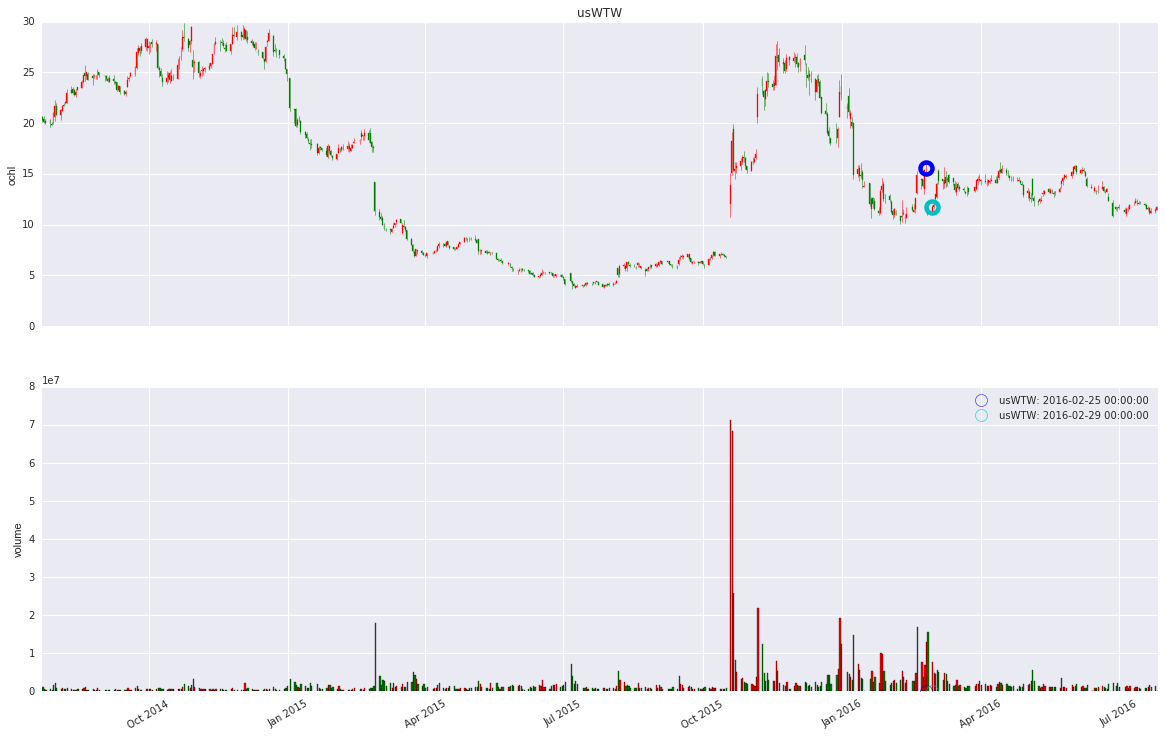

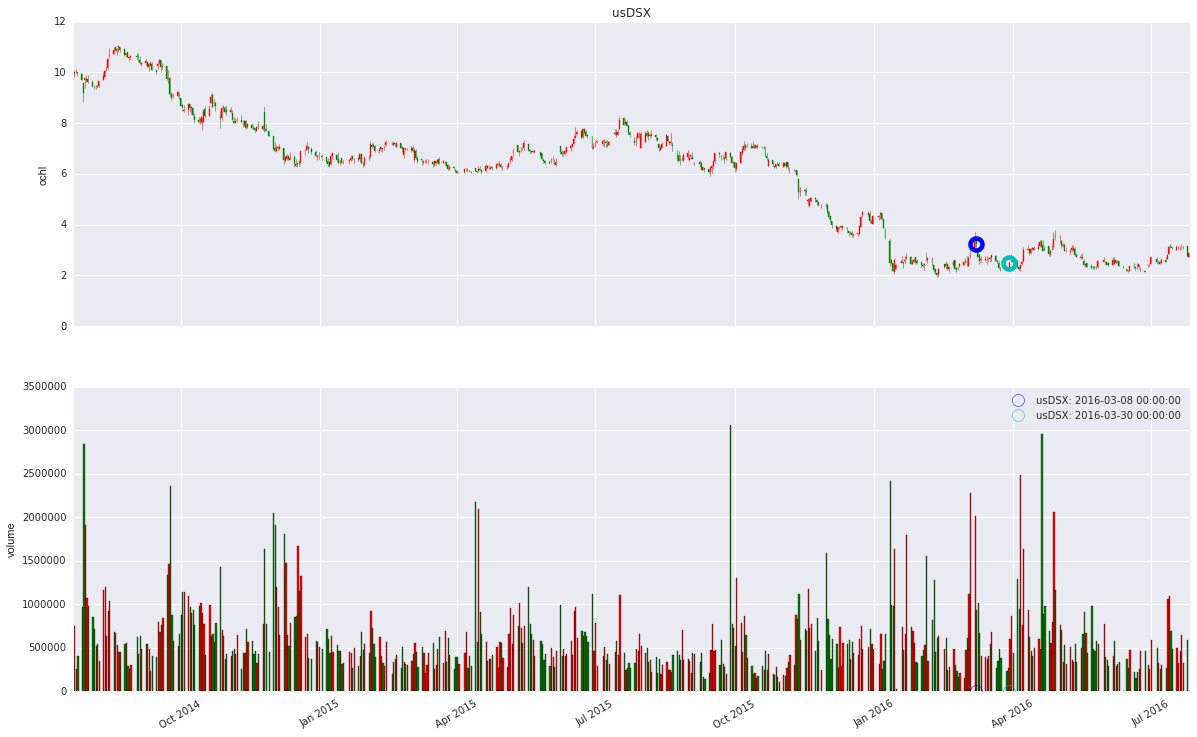

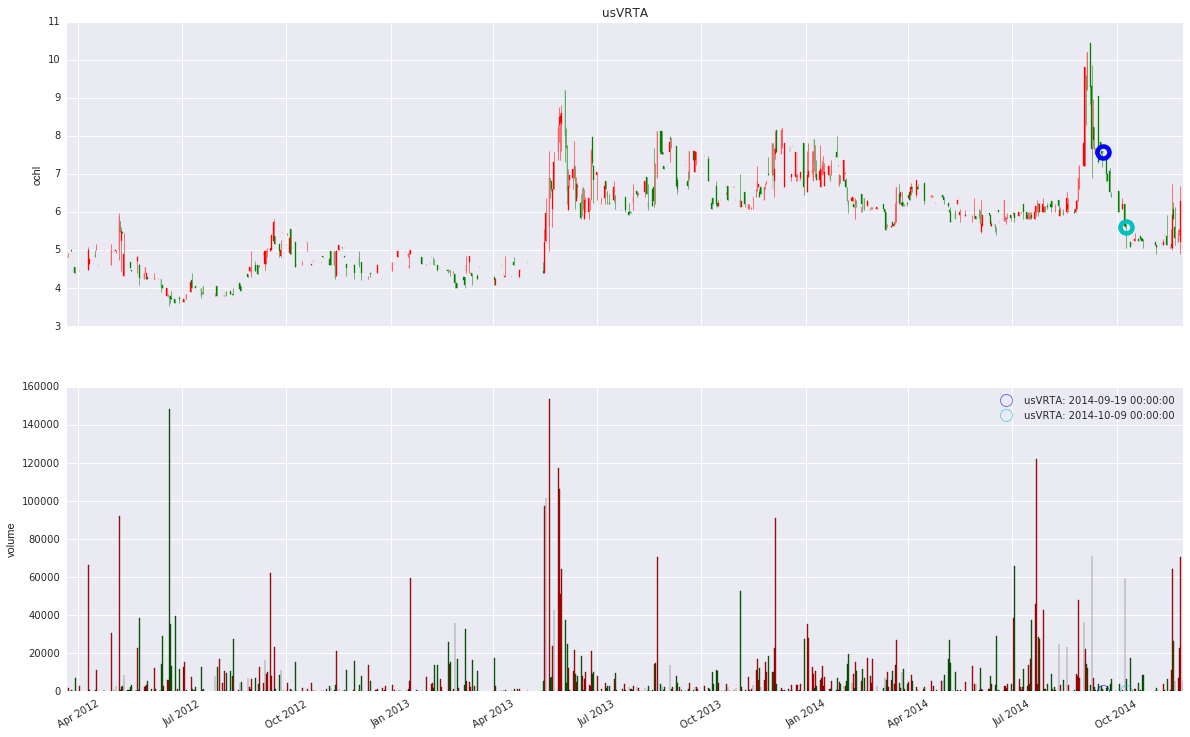

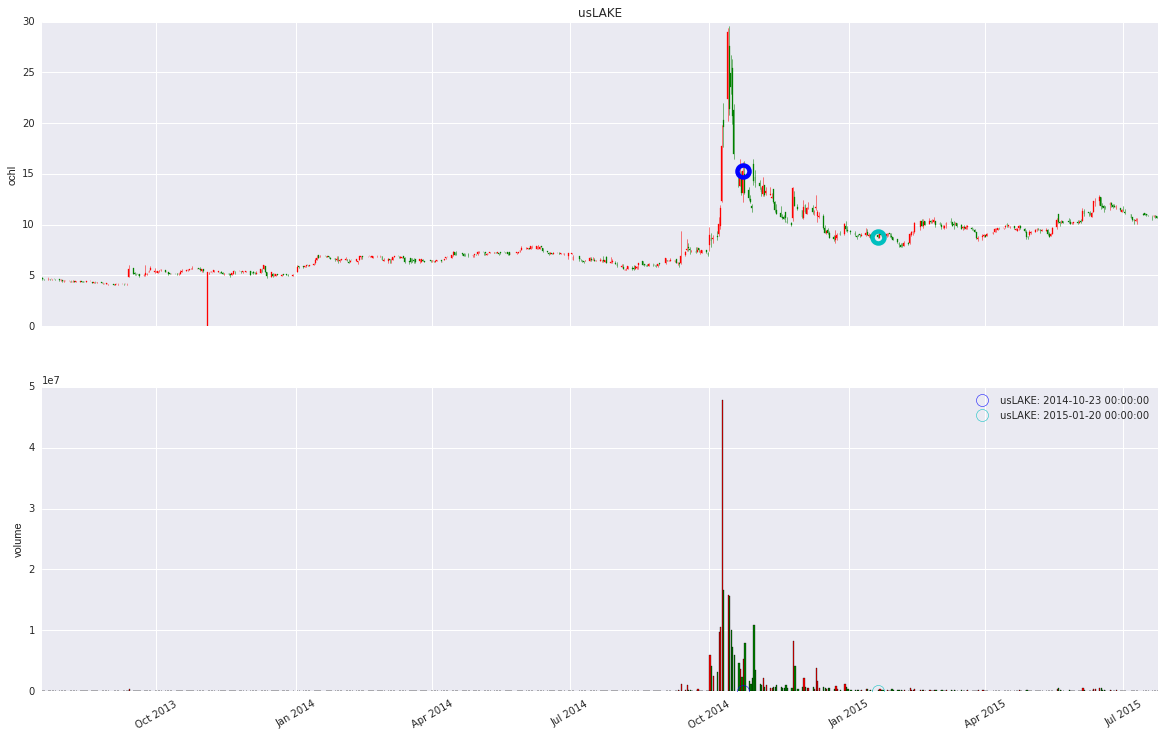

Timestamp('2014-12-16 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2014-12-16 00:00:00') is not in list


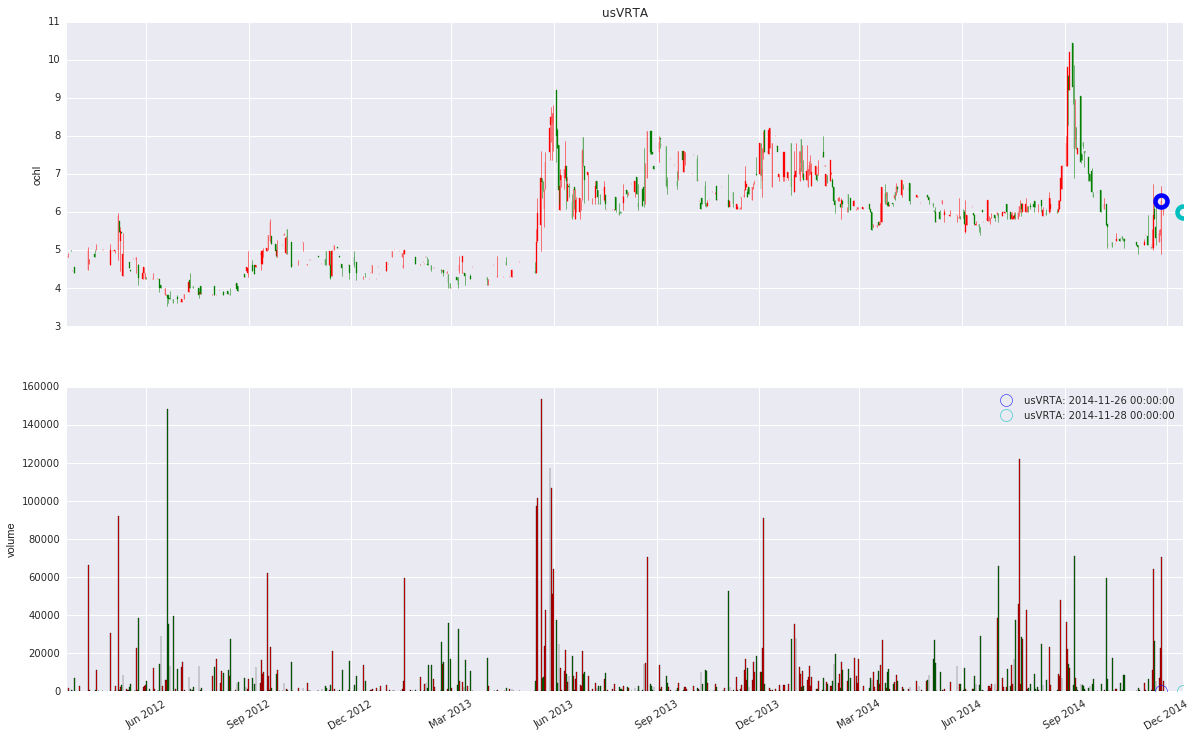

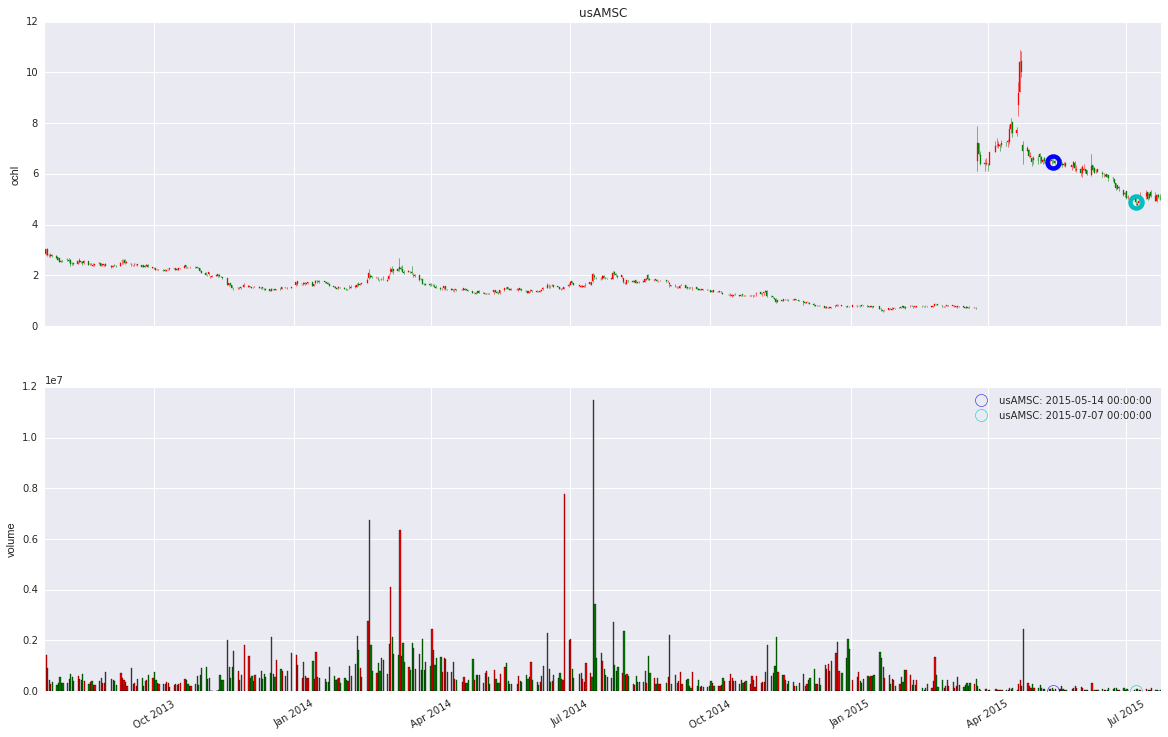

Timestamp('2015-06-30 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-06-30 00:00:00') is not in list
Timestamp('2015-07-08 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-07-08 00:00:00') is not in list


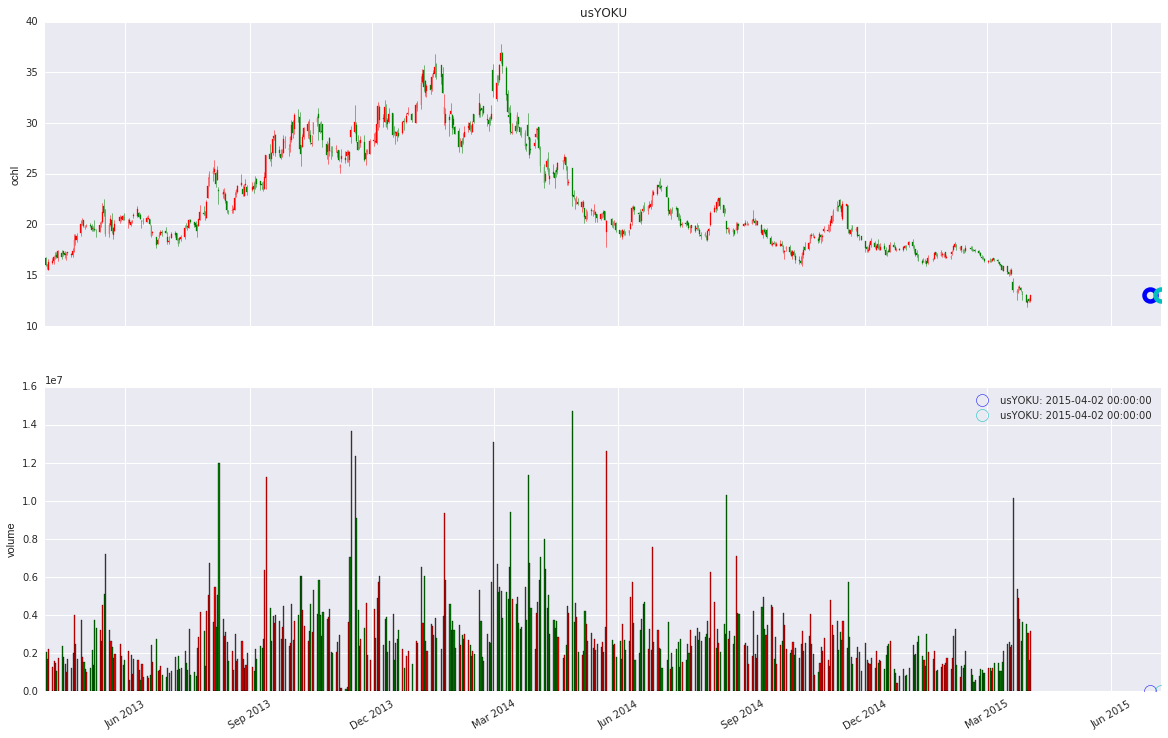

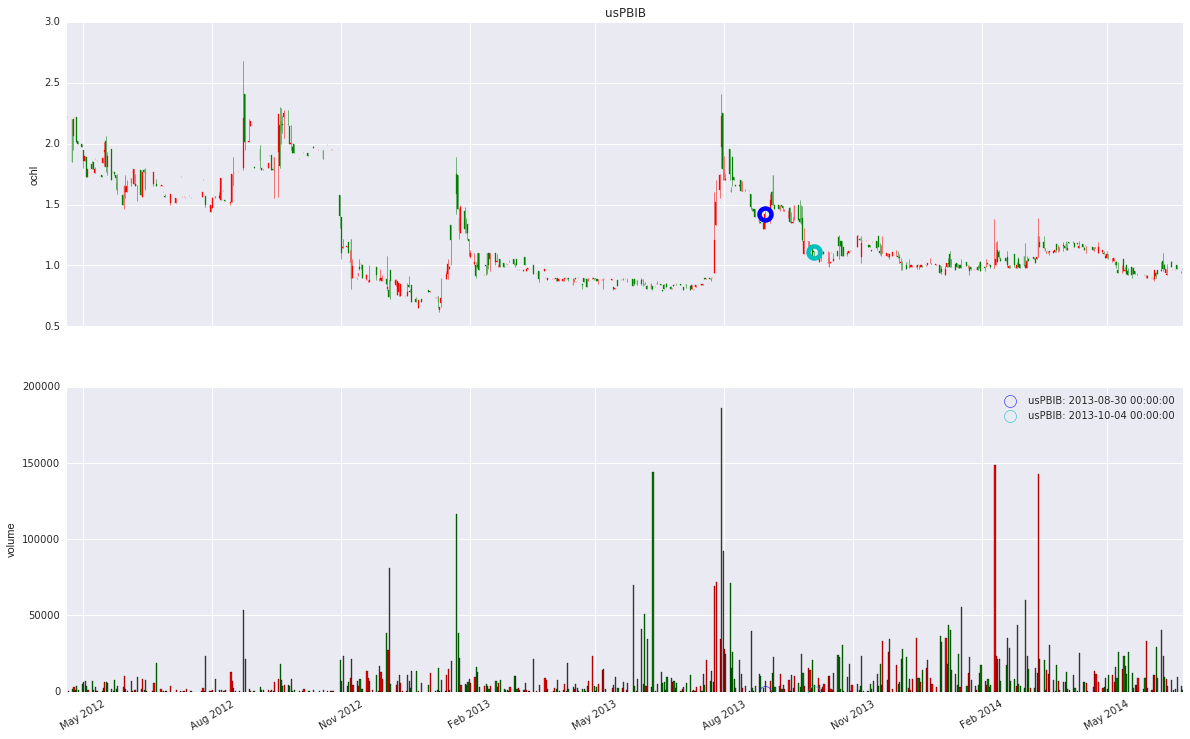

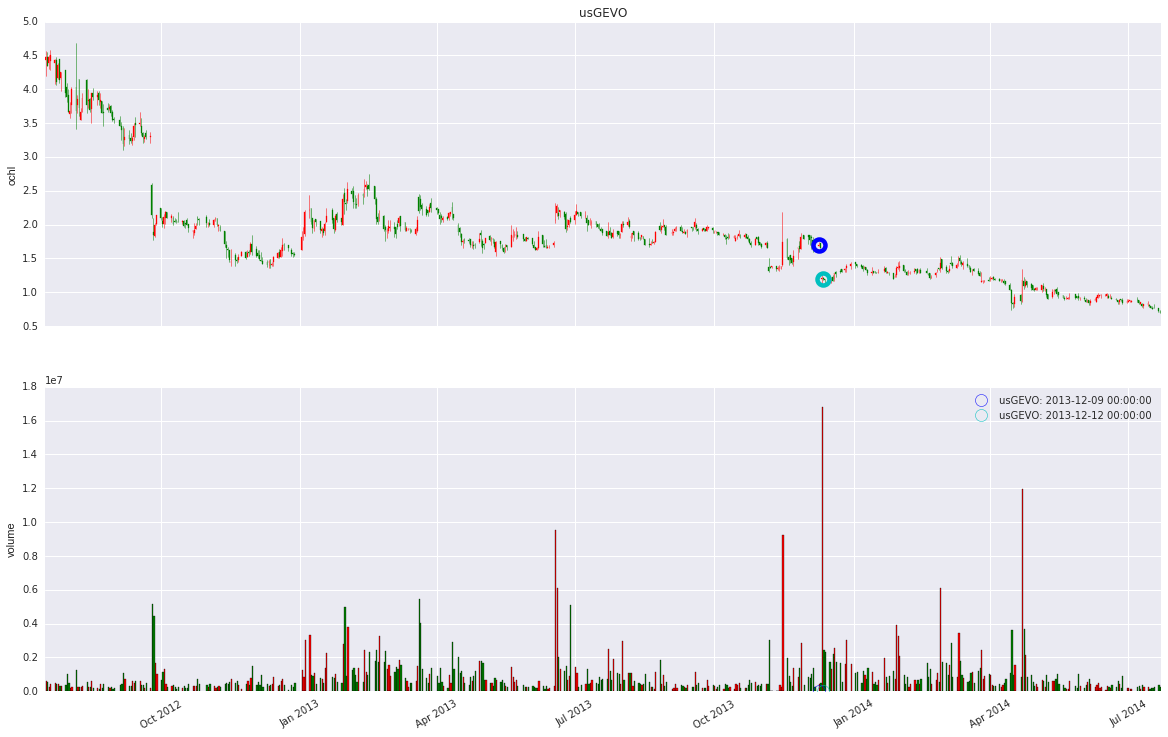

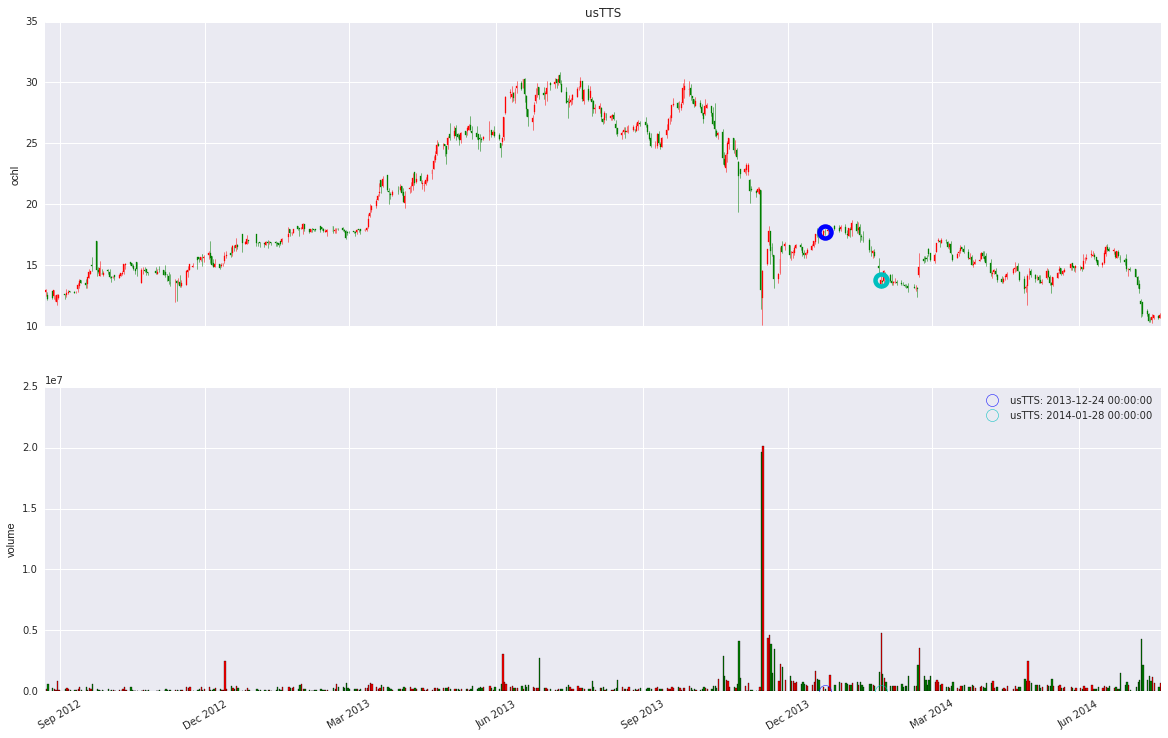

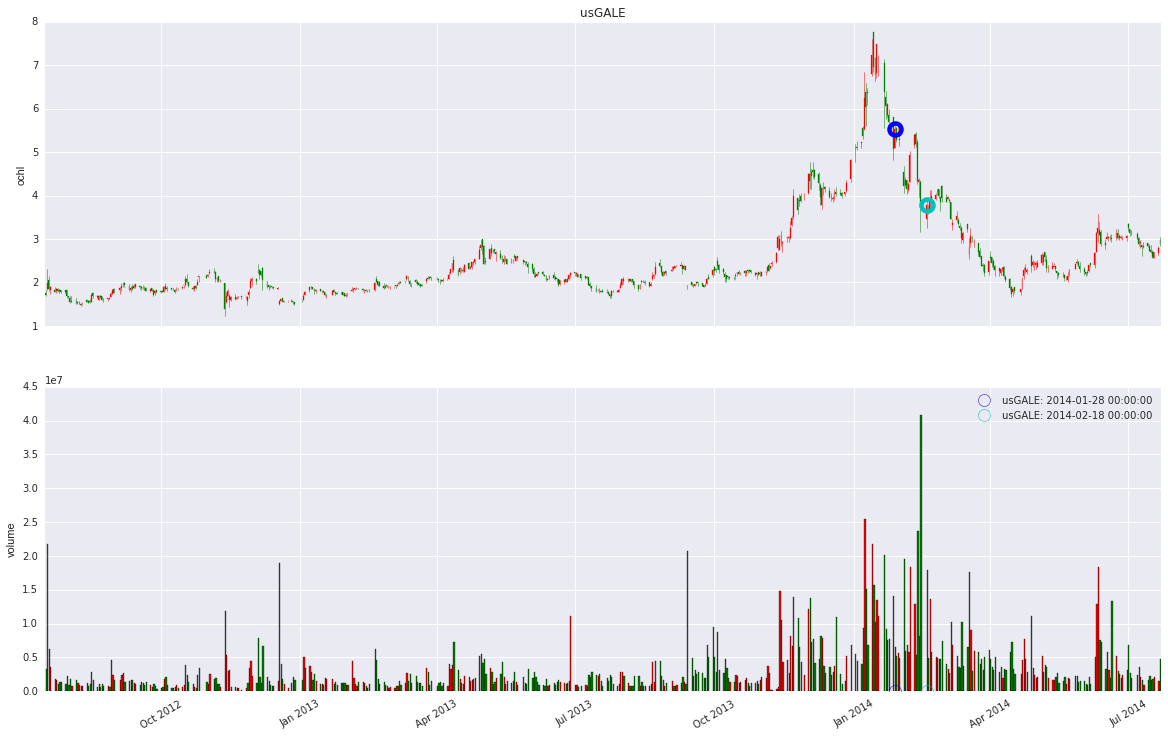

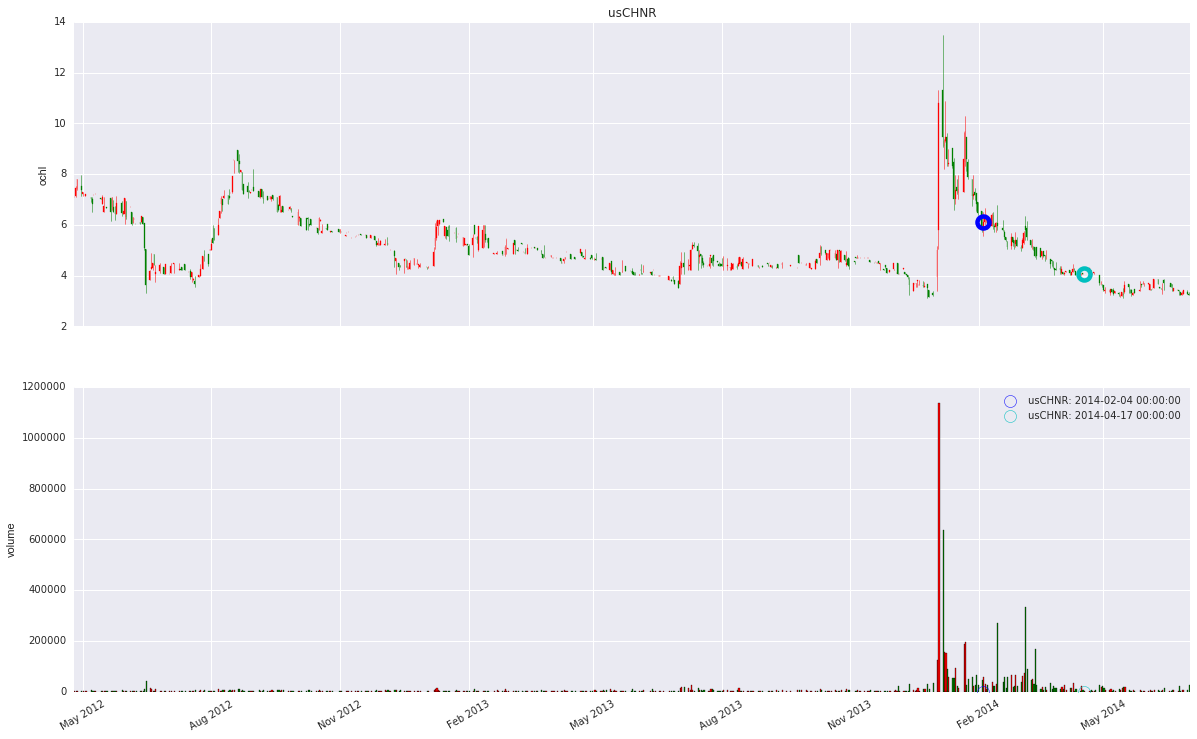

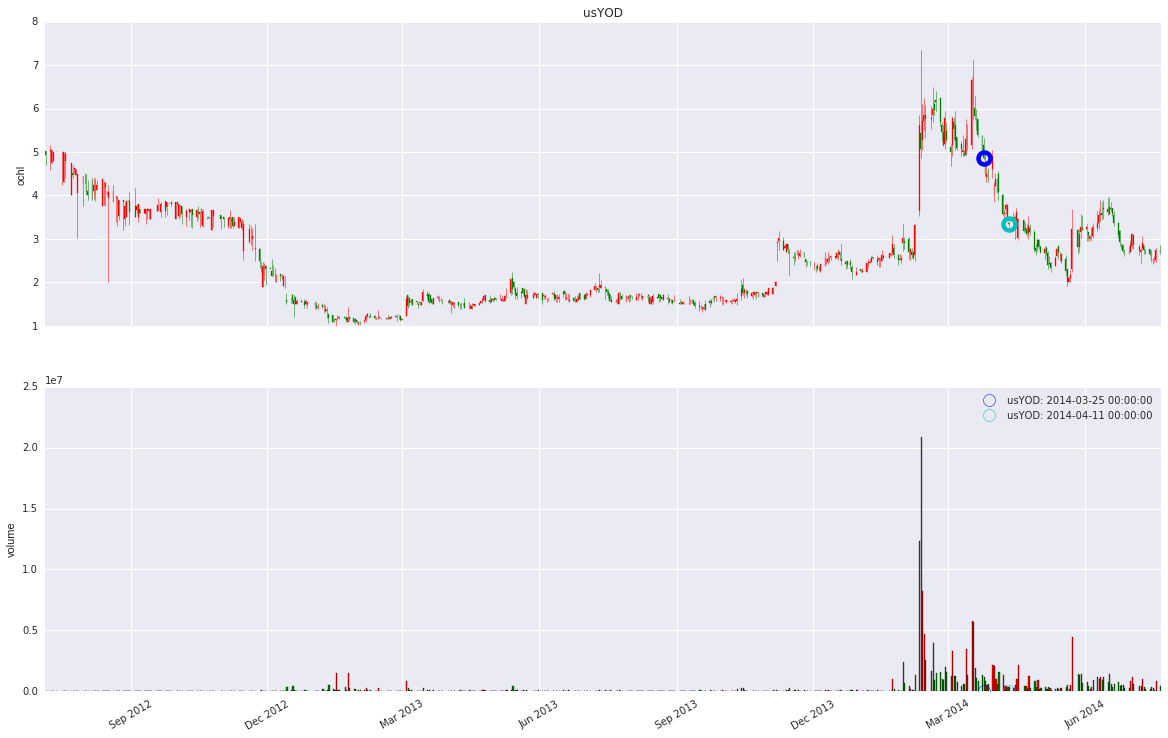

Timestamp('2013-02-21 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2013-02-21 00:00:00') is not in list
Timestamp('2013-04-17 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2013-04-17 00:00:00') is not in list


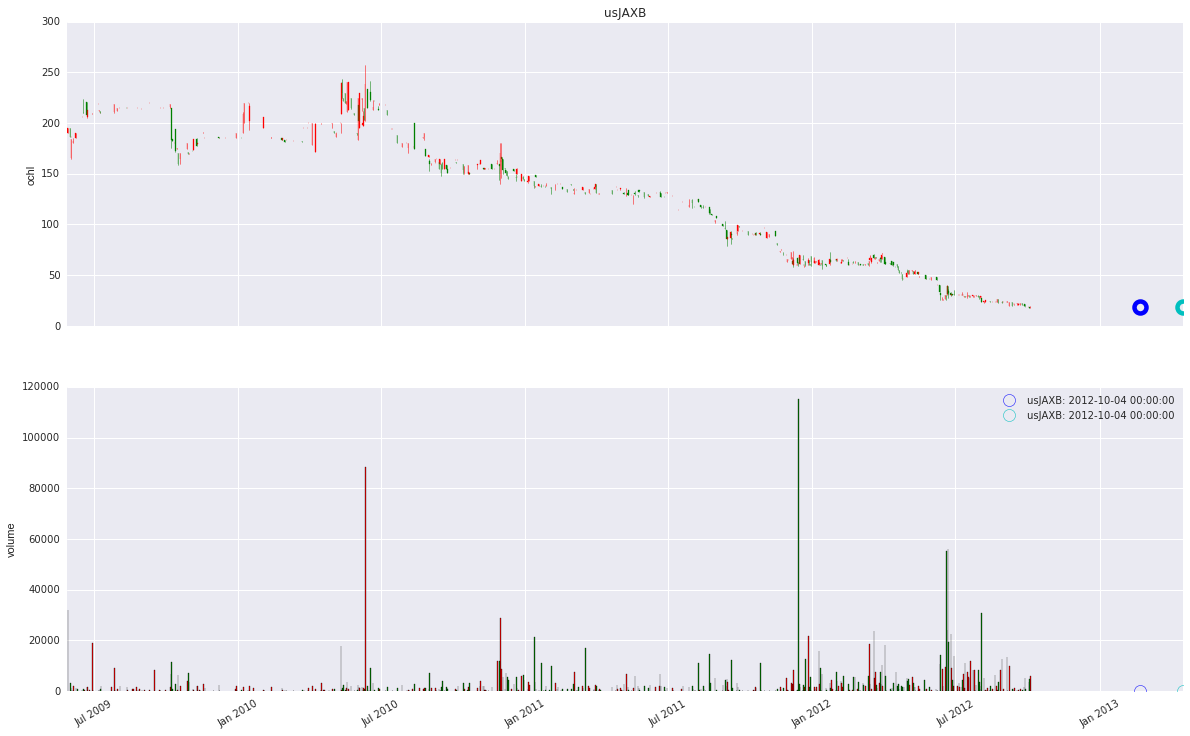

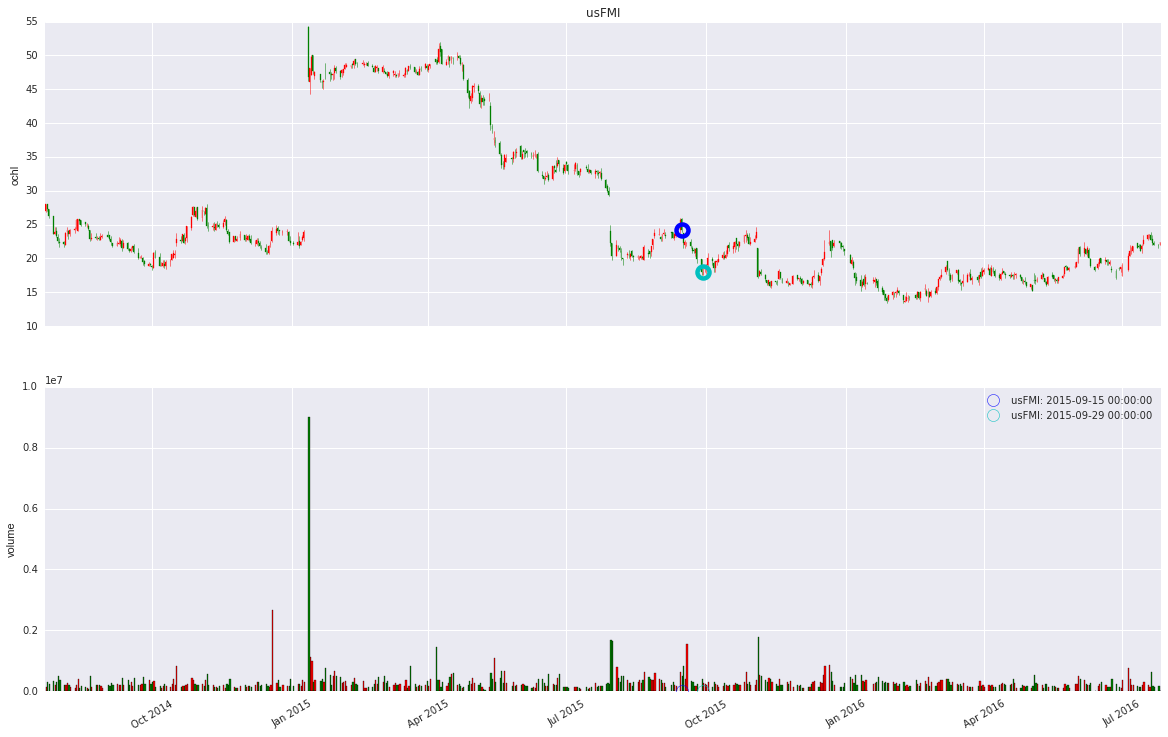

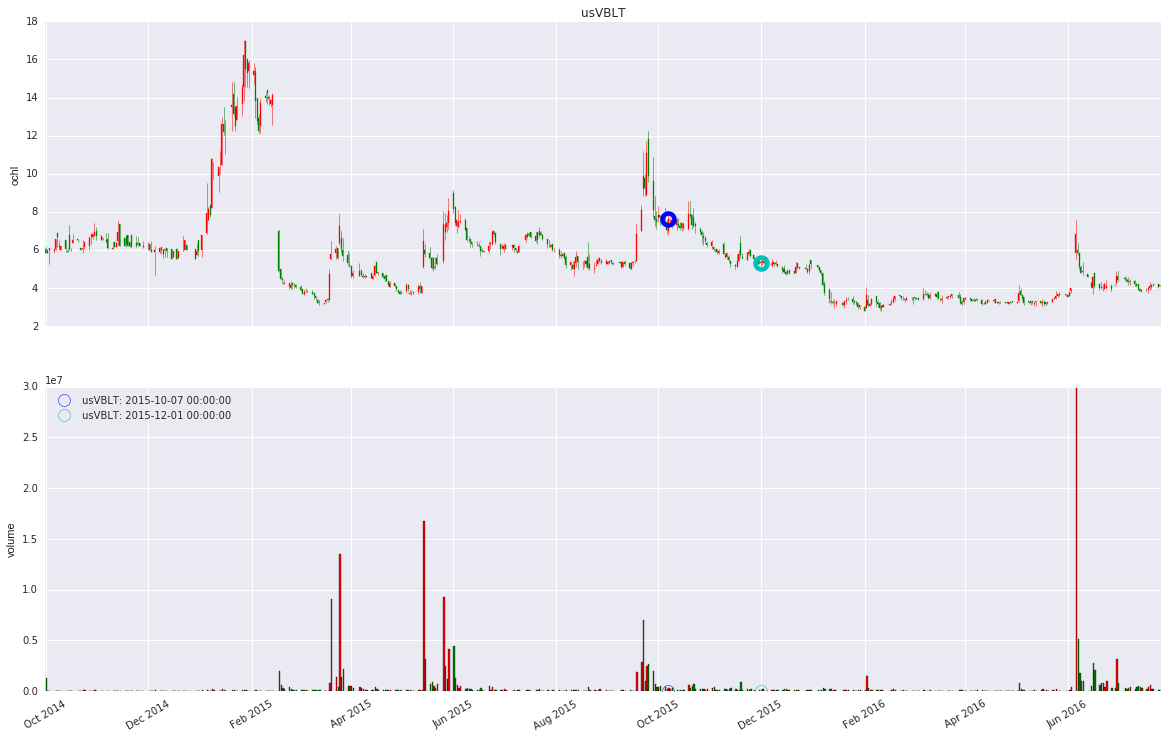

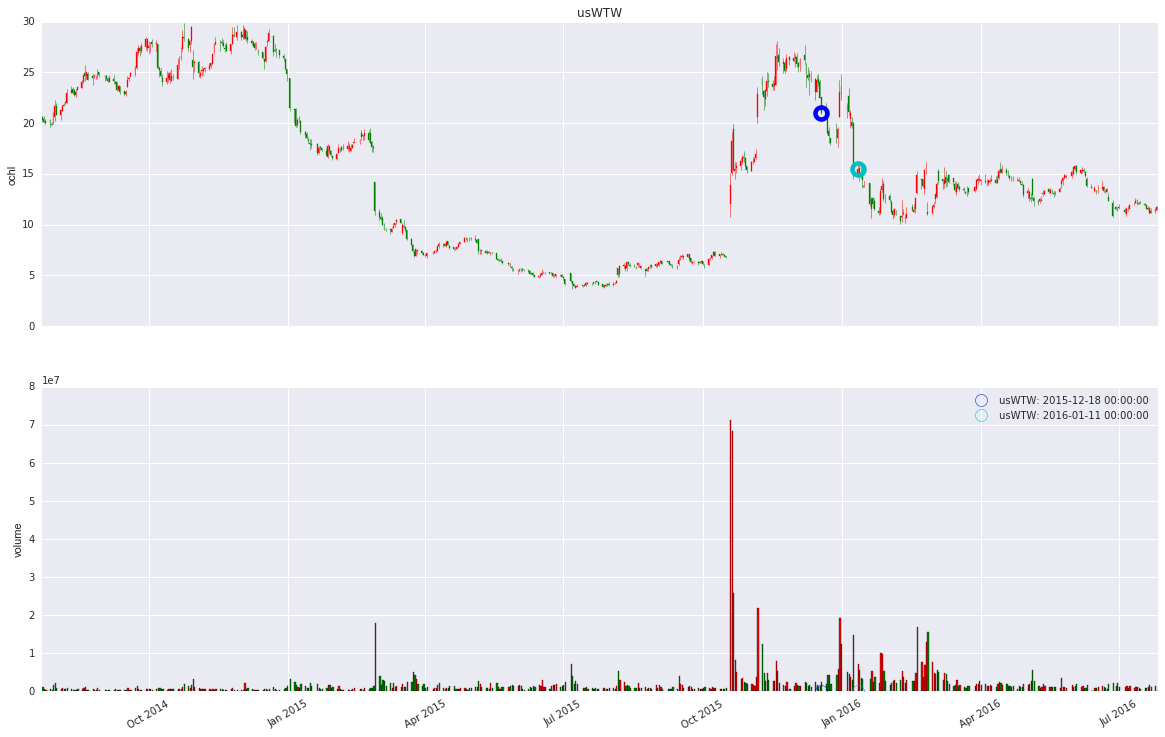

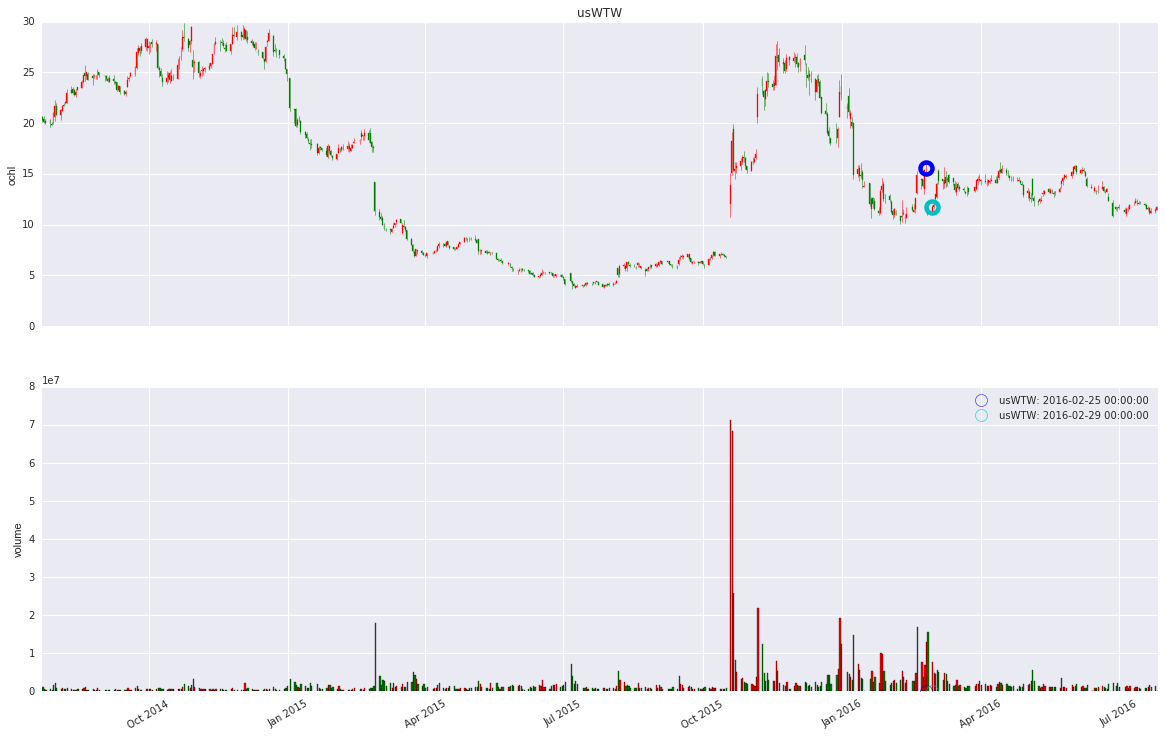

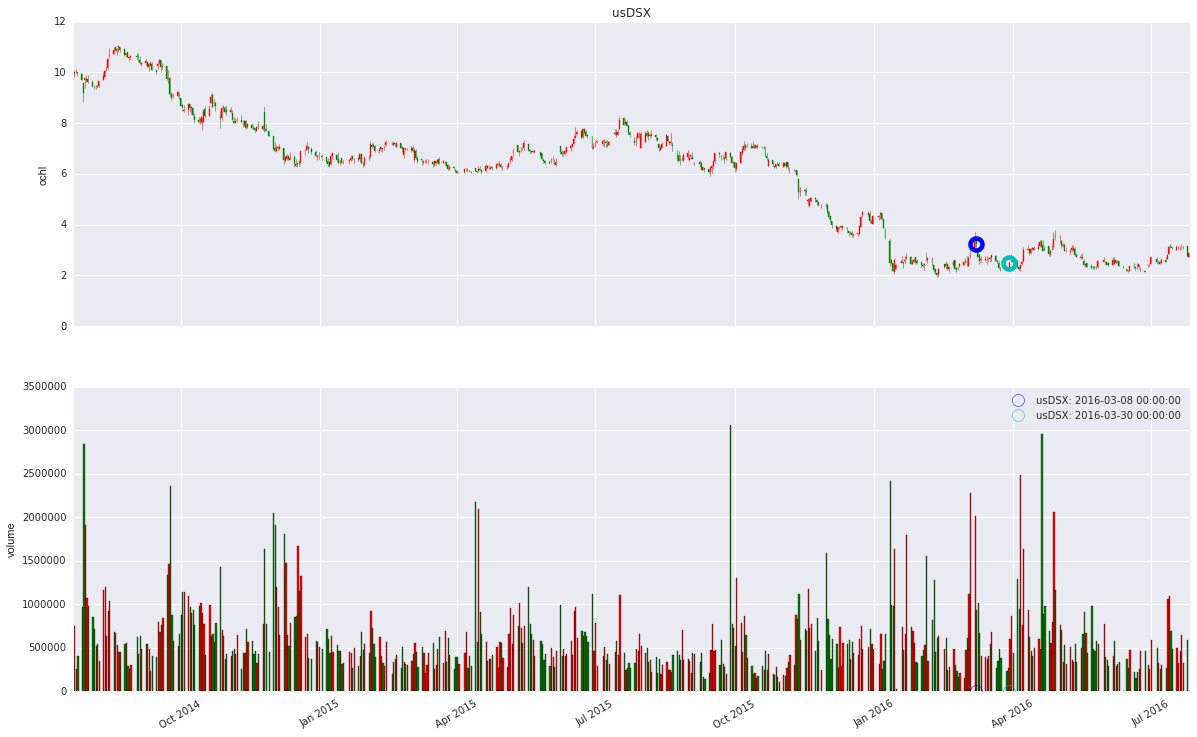

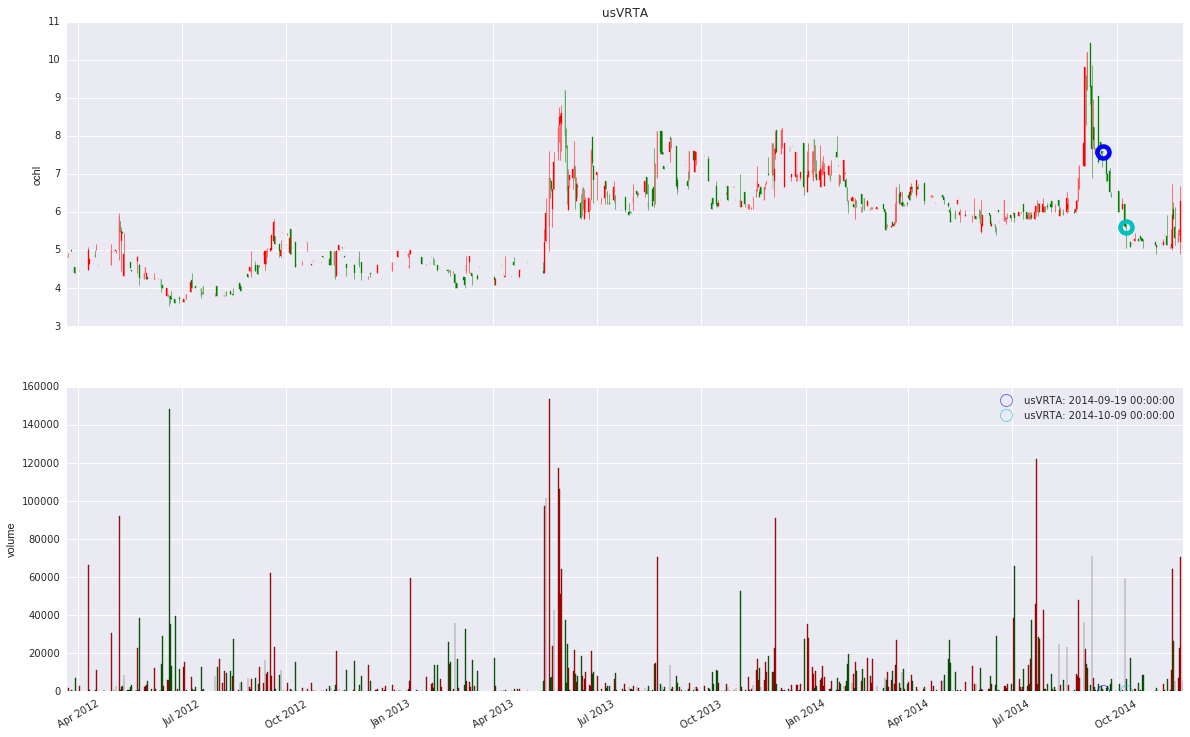

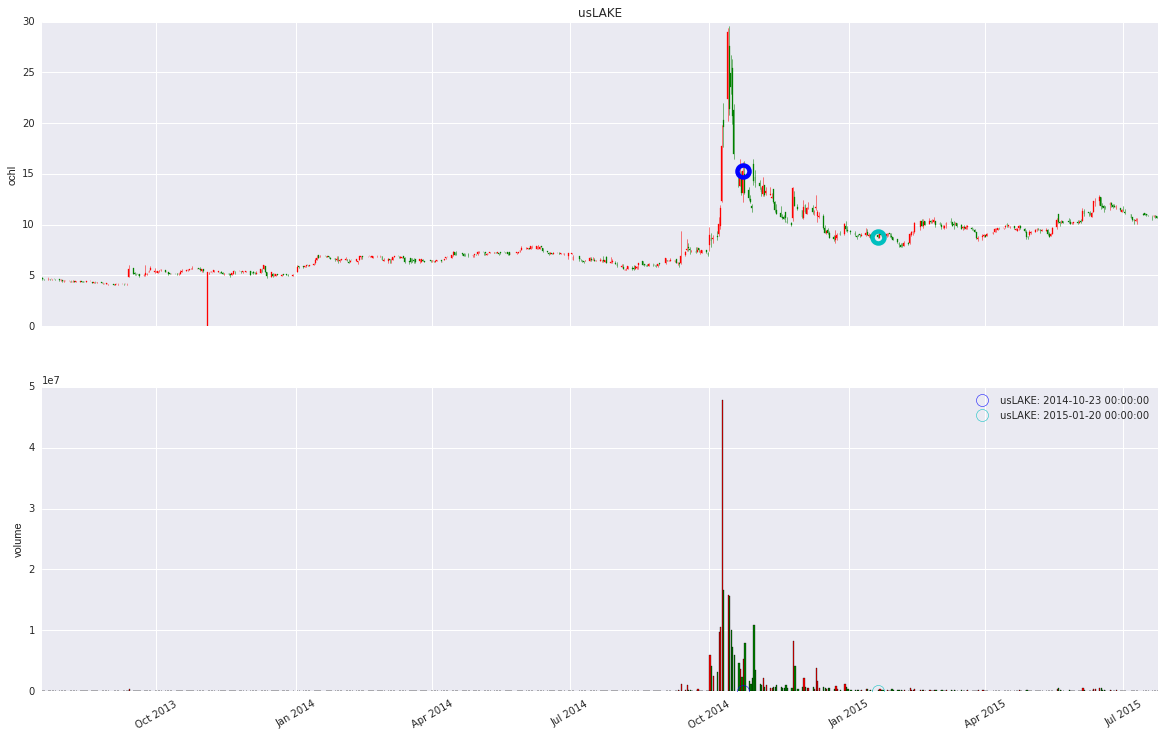

Timestamp('2014-12-16 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2014-12-16 00:00:00') is not in list


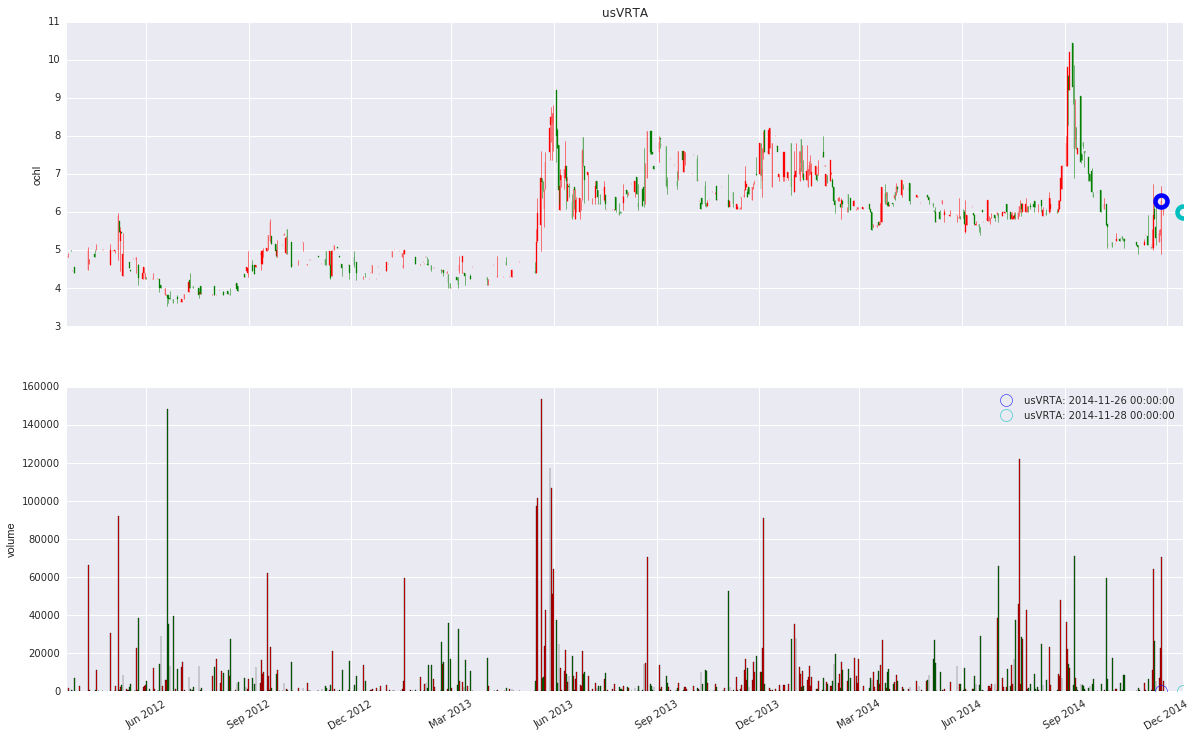

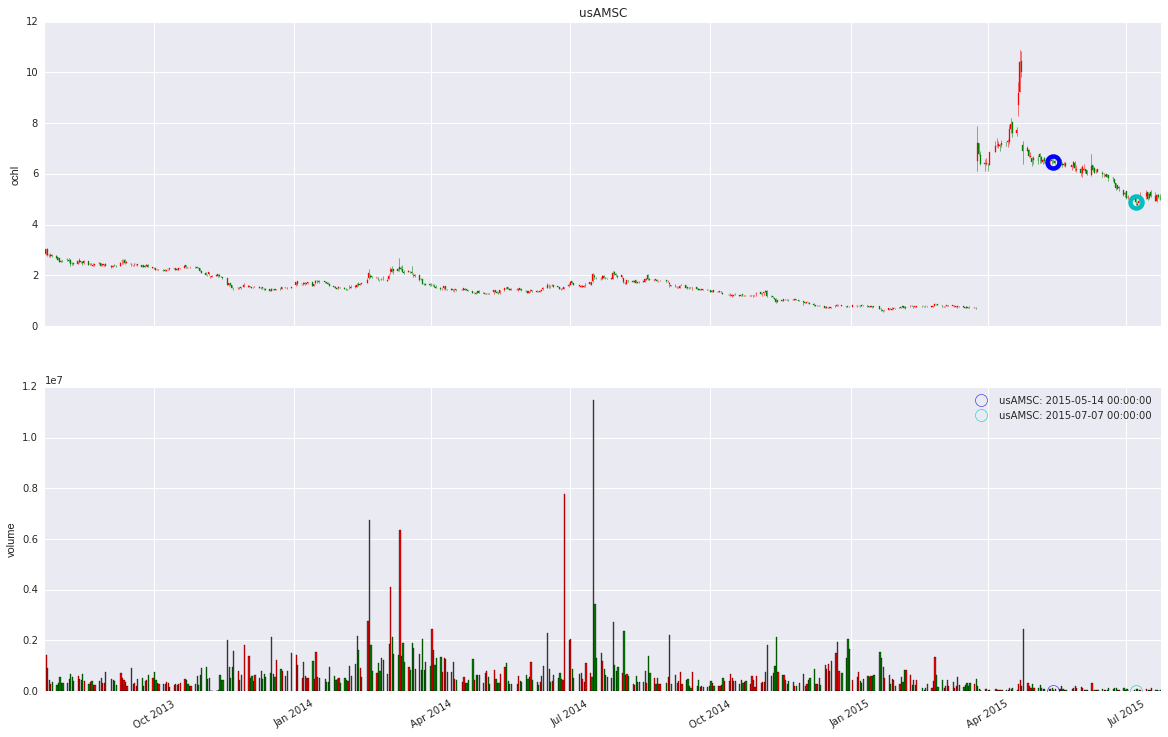

Timestamp('2015-06-30 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-06-30 00:00:00') is not in list
Timestamp('2015-07-08 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2015-07-08 00:00:00') is not in list


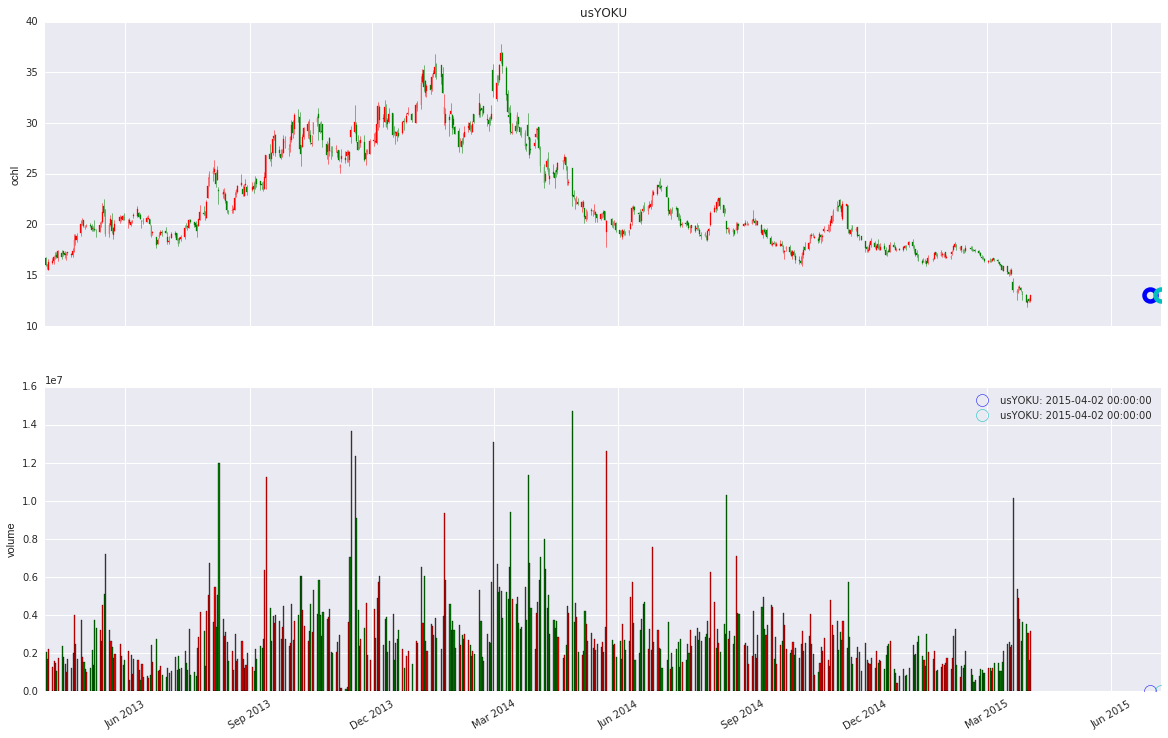

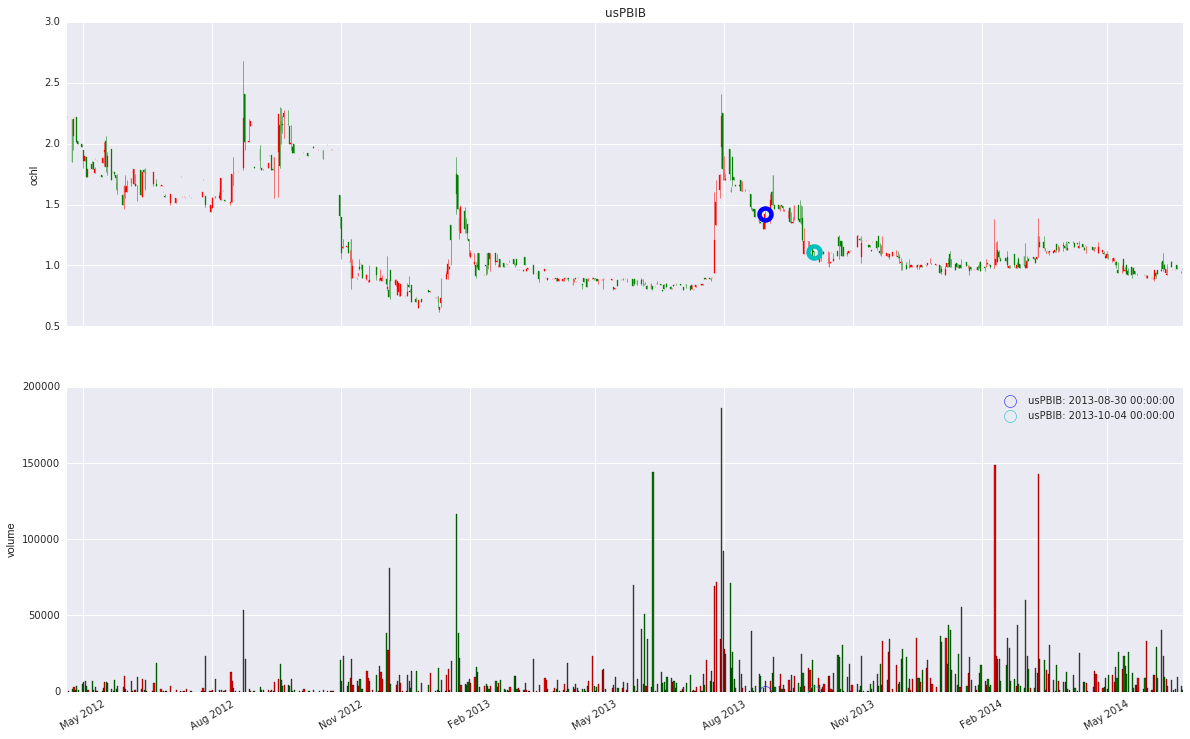

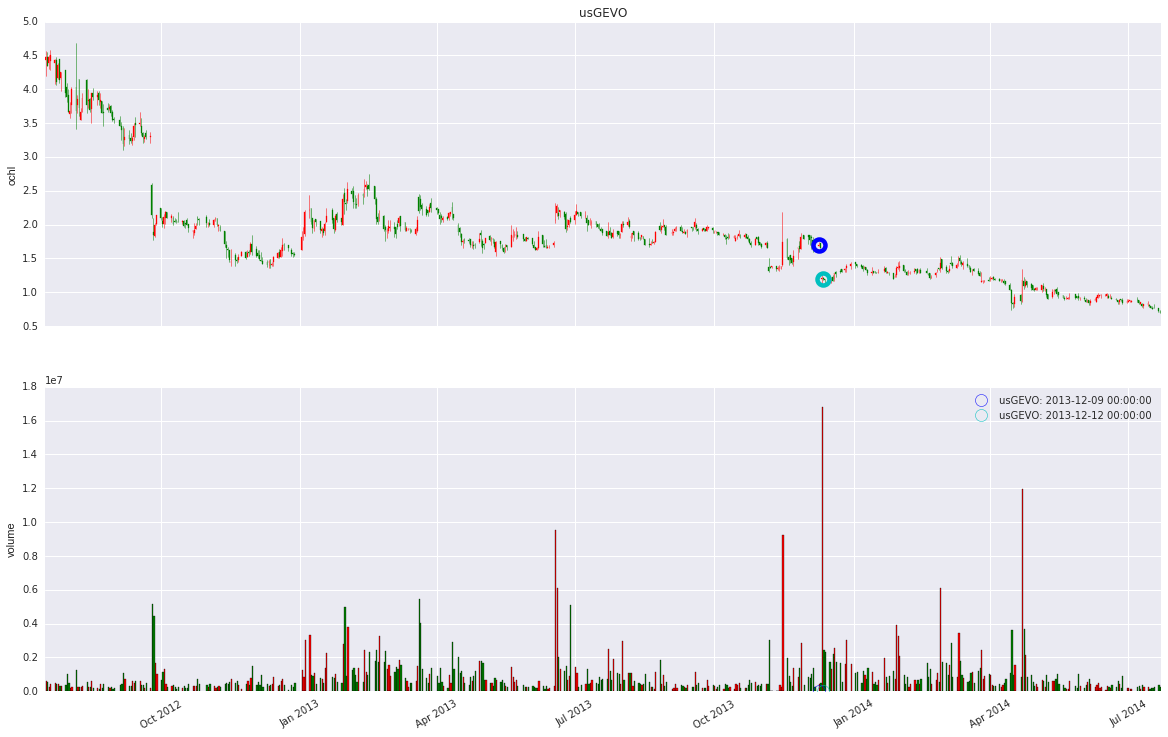

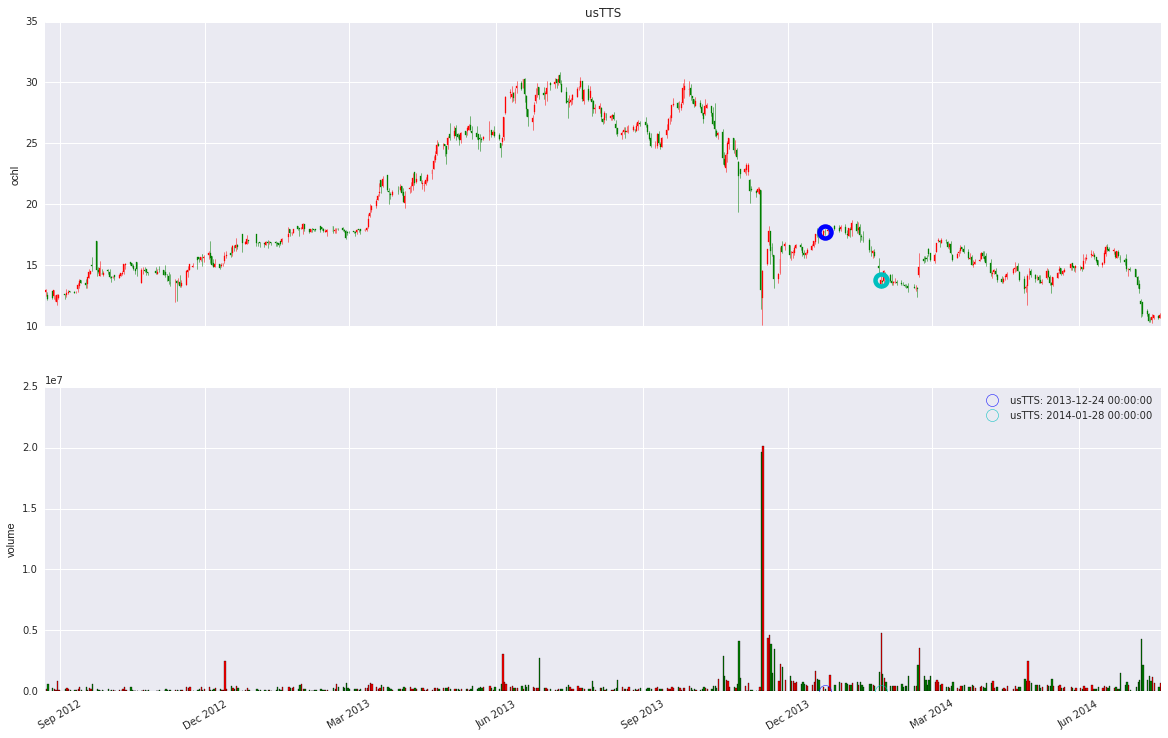

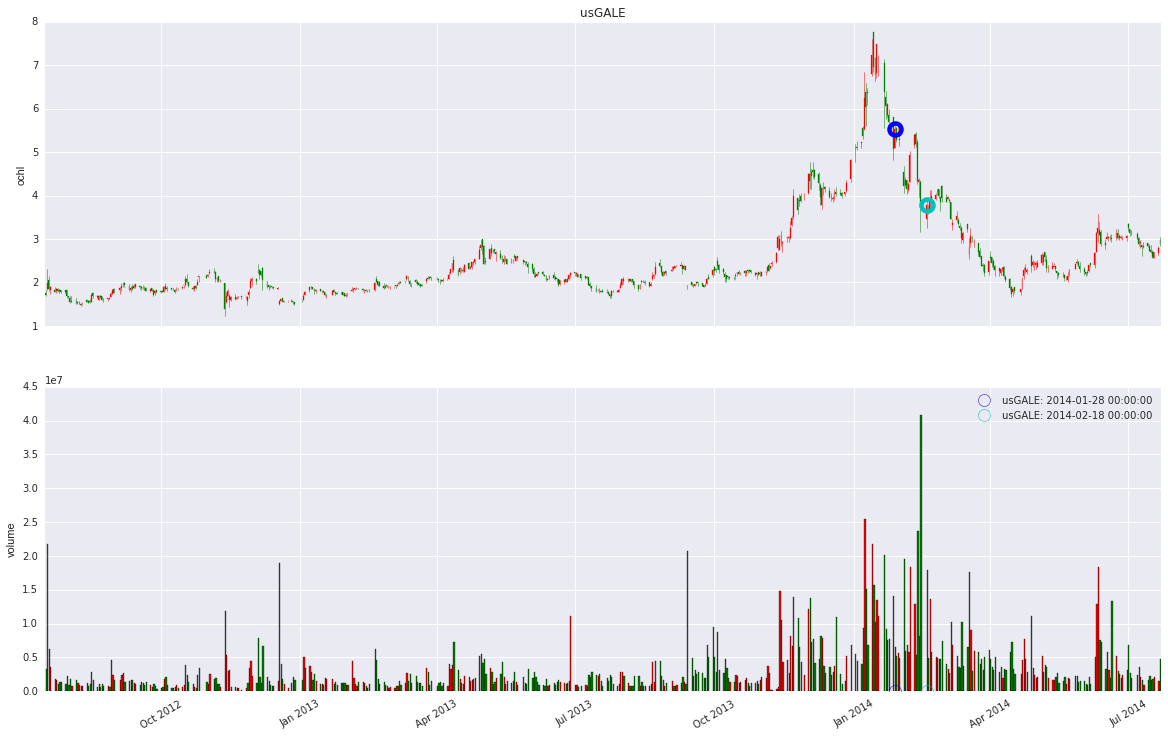

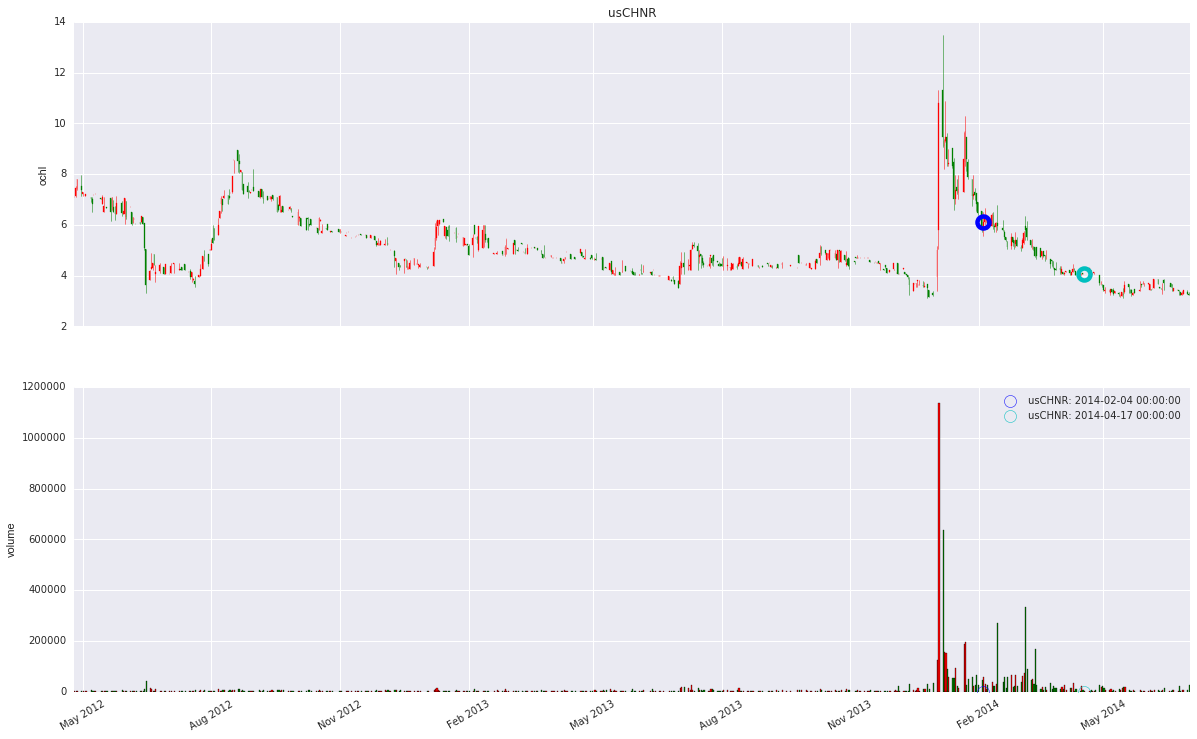

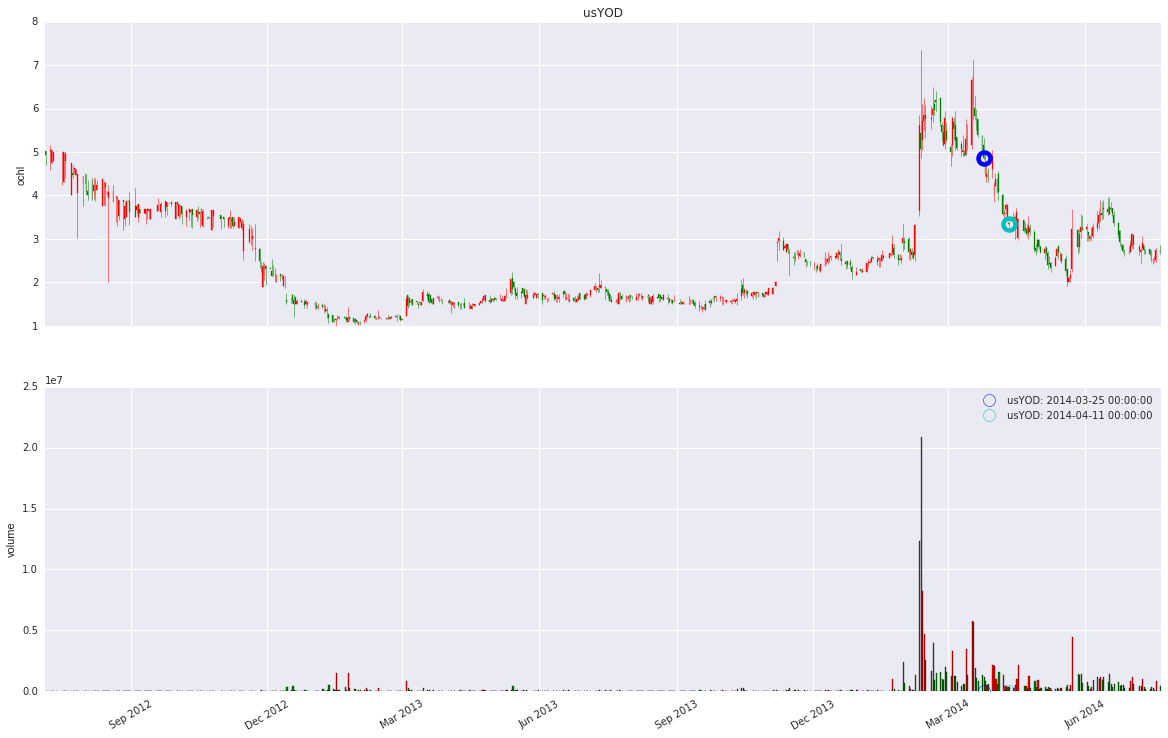

Timestamp('2013-02-21 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2013-02-21 00:00:00') is not in list
Timestamp('2013-04-17 00:00:00') is not in list
Traceback (most recent call last):
  File "/Users/Bailey/Desktop/my_work/stock_fact/Market/MarketDrawer.py", line 229, in _do_plot_candle
    v_index_num = e_list.index(viewIndex)
ValueError: Timestamp('2013-04-17 00:00:00') is not in list


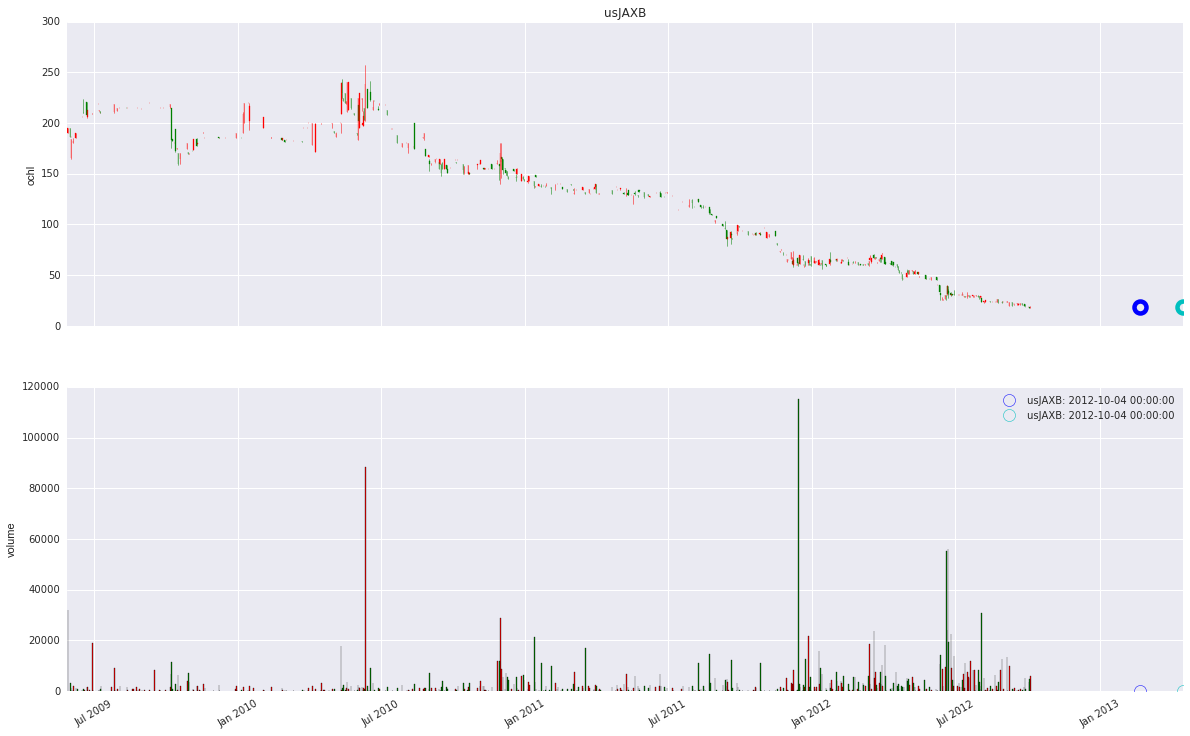

ValueError: ('get_n_year n_year > n_n_year!', u'occurred at index 2012-01-30 00:00:00')

In [179]:
MarketDrawer.plot_candle_from_order(unsame_order[unsame_order.profit_cg < -0.20])

交互式寻找是否提高原始rate就能得到更高的impove

nts_pd.shape = (2215, 9)
nts_pd loss rate = 0.634762979684
improved rate = 0.0148072821072
predict win rate = 0.515898606082


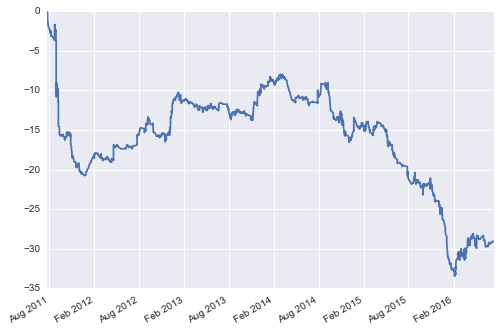

In [9]:
lps_range = (round(train_ump.cprs['lps'].min(), 2), round(train_ump.cprs['lps'].max(), 2), 0.1)
lms_range = (round(train_ump.cprs['lms'].min(), 2), round(train_ump.cprs['lms'].max(), 2), 0.01)
lrs_range = (round(train_ump.cprs['lrs'].min(), 2), round(train_ump.cprs['lrs'].max(), 2), 0.01)
def interact_llps(lps, lms, lrs):
    it_llps = train_ump.cprs[(train_ump.cprs['lps'] <= lps) & (train_ump.cprs['lms'] <= lms)& (train_ump.cprs['lrs'] >=lrs)]
    if not it_llps.empty:
        train_ump.choose_cprs_component(it_llps)
from ipywidgets import interact
interact(interact_llps, lps=lps_range, lms=lms_range, lrs=lrs_range)

**使用视觉上感觉更好的进行回测**

In [186]:
llps = train_ump.cprs[(train_ump.cprs['lps'] <= -0.63) & (train_ump.cprs['lms'] <= -0.00 )& (train_ump.cprs['lrs'] >=0.68)]
train_ump.dump_clf(llps)
BuyGoldenFactor.g_enable_fiter = True
buy_factors = [{'XD': 42, 'class': BuyGoldenFactorClass, 'draw': True}]
out, orders_pd_test_enable_fiter2 = MetricsManger.make_metrics_rsc_mul_symbol_grid(buy_factors, n_folds=6, 
    score_type=METRICSTYPE.SYSMBOL_R_SCORES_GOLDEN.value, ret_cnt_need=0, train_test_split=False, 
    use_last_test=True, force_one_process=False)

In [191]:
# fn = './data/cache/golden_n6_enable_fiter_best2_abu'
# key = 'golden_n6_enable_fiter_best2_abu'
# ZCommonUtil.dump_hdf5(orders_pd_test_enable_fiter2, key, fn)
# orders_pd_test_enable_fiter2 = ZCommonUtil.load_hdf5(fn, key)

**还没之前的好**

all fit order = (4477, 31)
win rate = 0.50033504579
profit_cg.sum() = 25.0138982168
win mean = 0.0712054456398 loss_mean = -0.0601899144826 


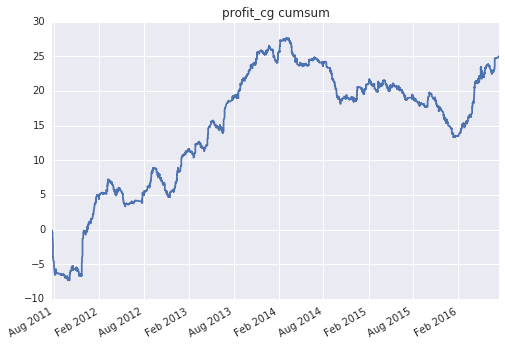

In [187]:
StatsOrdersClass(orders_pd_test_enable_fiter2, MlFiterGoldenPdClass).show_general()

可视化找到0， 0， 0.65有2215个
修改需要命中分类列的数量，
BuyGoldenFactor.g_fiter_ind_cnt = 3
看看效果

In [10]:
llps = train_ump.cprs[(train_ump.cprs['lps'] <= 0) & (train_ump.cprs['lms'] <= 0 )& (train_ump.cprs['lrs'] >=0.65)]
train_ump.dump_clf(llps)
BuyGoldenFactor.g_enable_fiter = True
BuyGoldenFactor.g_fiter_ind_cnt = 3
buy_factors = [{'XD': 42, 'class': BuyGoldenFactorClass, 'draw': True}]
out, orders_pd_test_enable_fiter_ = MetricsManger.make_metrics_rsc_mul_symbol_grid(buy_factors, n_folds=6, 
    score_type=METRICSTYPE.SYSMBOL_R_SCORES_GOLDEN.value, ret_cnt_need=0, train_test_split=False, 
    use_last_test=True, force_one_process=False)

all fit order = (4433, 31)
win rate = 0.503270922626
profit_cg.sum() = 27.1601525082
win mean = 0.0707998795309 loss_mean = -0.0594687205126 


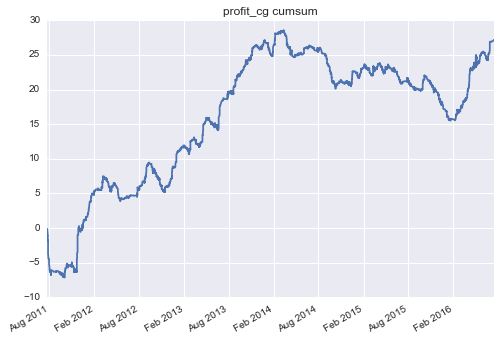

In [11]:
StatsOrdersClass(orders_pd_test_enable_fiter_, MlFiterGoldenPdClass).show_general()

win rate还是比0.504稍小但是profit_cg.sum却高出一点了

### ‘非均衡胜负收益’带来的必然’非均衡胜负比例‘，目标由’因子‘的能力解决一部分，’模式识别‘提升关键的一部分